In [28]:
import seaborn as sns
import pandas as pd
import numpy as np
import tkinter as tk
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from tkinter import filedialog
from scipy.stats import shapiro, anderson
from scipy import stats

In [2]:
def load_dataframe_from_path(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
        
    elif ext in [".otus", ".txt", ".meta", ".taxonomy"]:
        df = pd.read_csv(path, sep="\t")
        
    else:
        raise ValueError(
            f"Formato no soportado: {ext}. "
            "Usa archivos .csv, .otus, .txt, .meta o .taxonomy"
        )

    return df


def load_multiple_dataframes():
    root = tk.Tk()
    root.withdraw()  
    root.attributes("-topmost", True)  

    file_paths = filedialog.askopenfilenames(
        title="Selecciona uno o varios datasets",
        filetypes=[
            ("Archivos soportados", "*.csv *.otus *.txt *.meta *.taxonomy"),
            ("CSV", "*.csv"),
            ("OTUS", "*.otus"),
            ("TXT", "*.txt"),
            ("META", "*.meta"),
            ("TAXONOMY", "*.taxonomy"),
            ("Todos los archivos", "*.*")
        ]
    )

    if not file_paths:
        print("No se seleccionó ningún archivo.")
        return {}

    dataframes = {}

    for file_path in file_paths:
        path = Path(file_path)
        try:
            df = load_dataframe_from_path(path)
            dataframes[path.stem] = df
            print(f"Cargado: {path.name} -> shape {df.shape}")
        except Exception as e:
            print(f"Error al cargar {path.name}: {e}")

    return dataframes

In [3]:
dfs = load_multiple_dataframes()

if not dfs:
    print("No se cargó ningún archivo.")
else:
    for nombre, df in dfs.items():
        print(f"\nArchivo cargado: {nombre}")
        print(f"Shape del DataFrame: {df.shape}")
        print(f"Columnas: {df.columns.tolist()[:10]}{' ...' if len(df.columns) > 10 else ''}")

Cargado: anthro_data.meta -> shape (441, 33)
Cargado: otu_data_converted.csv -> shape (441, 4739)

Archivo cargado: anthro_data
Shape del DataFrame: (441, 33)
Columnas: ['ID', 'city', 'socioeconomic', 'sex', 'age', 'age_range', 'HDL', 'LDL', 'cholesterol', 'triglycerides'] ...

Archivo cargado: otu_data_converted
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009'] ...


In [4]:
otu_df = dfs["otu_data_converted"]
anthro_df = dfs["anthro_data"]
dfs.keys()
#otu_df.head()
#anthro_df.head()

dict_keys(['anthro_data', 'otu_data_converted'])

In [5]:
def get_numeric_df(df, numeric_cols=None):

    if numeric_cols is None:
        df_num = df.select_dtypes(include=[np.number]).copy()
    else:
        missing = [c for c in numeric_cols if c not in df.columns]
        if missing:
            raise KeyError(f"Estas columnas no existen en el DataFrame: {missing}")

        df_num = df[numeric_cols].copy()

        for col in df_num.columns:
            df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

        df_num = df_num.select_dtypes(include=[np.number])

    if df_num.empty:
        raise ValueError("El DataFrame no contiene columnas numéricas para analizar.")

    return df_num


def flatten_numeric_values(df_num):

    valores = df_num.to_numpy(dtype=float).ravel()
    valores = valores[np.isfinite(valores)]
    return valores


def summarize_flat_values(df_original, df_num, valores):

    valores_pos = valores[valores > 0]

    summary = {
        "shape_original": df_original.shape,
        "shape_numeric": df_num.shape,
        "n_total_finitos": int(len(valores)),
        "n_positivos": int(len(valores_pos)),
        "n_ceros": int(np.sum(valores == 0)),
        "min": float(np.min(valores)) if len(valores) > 0 else np.nan,
        "max": float(np.max(valores)) if len(valores) > 0 else np.nan,
        "mean": float(np.mean(valores)) if len(valores) > 0 else np.nan,
        "median": float(np.median(valores)) if len(valores) > 0 else np.nan,
        "std": float(np.std(valores, ddof=1)) if len(valores) > 1 else np.nan,
    }

    return summary


def plot_flat_scatter(valores, figsize=(10, 4), title="Valores numéricos (incluye ceros)"):

    plt.figure(figsize=figsize)
    plt.scatter(np.arange(len(valores)), valores, s=10, alpha=0.6, edgecolor="none")
    plt.title(title)
    plt.xlabel("Índice (aplanado)")
    plt.ylabel("Valor")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_histogram(valores, bins=100, figsize=(10, 4), title="Histograma", xlabel="Valor"):

    plt.figure(figsize=figsize)
    sns.histplot(valores, bins=bins, kde=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

In [8]:
def distribution_plots_from_loaded(
    dfs,
    df_name,
    numeric_cols=None,
    analysis_mode="by_column",   # "by_column", "full_matrix", "both"
    bins=100,
    plot_positive_hist=True,
    figsize_scatter=(10, 4),
    figsize_hist=(10, 4),
    verbose=True
):
    if df_name not in dfs:
        raise KeyError(f"No existe '{df_name}' en dfs. Disponibles: {list(dfs.keys())}")

    if analysis_mode not in ["by_column", "full_matrix", "both"]:
        raise ValueError("analysis_mode debe ser 'by_column', 'full_matrix' o 'both'.")

    df = dfs[df_name].copy()
    df_num = get_numeric_df(df, numeric_cols=numeric_cols)

    if df_num.empty:
        raise ValueError("El DataFrame no contiene columnas numéricas para analizar.")

    if verbose:
        print(f"DataFrame analizado: {df_name}")
        print(f"Shape original: {df.shape}")
        print(f"Shape numérico: {df_num.shape}")
        print(f"Columnas numéricas analizadas: {df_num.columns.tolist()}")
        print(f"Modo de análisis: {analysis_mode}")

    result = {
        "df_name": df_name,
        "df_numeric": df_num
    }

    # =====================================
    # A) Análisis por columna
    # =====================================
    if analysis_mode in ["by_column", "both"]:
        results = []

        for col in df_num.columns:
            serie = pd.to_numeric(df_num[col], errors="coerce")
            valores = serie.to_numpy(dtype=float)
            valores = valores[np.isfinite(valores)]
            valores_pos = valores[valores > 0]

            if len(valores) == 0:
                summary = {
                    "variable": col,
                    "n_total_finitos": 0,
                    "n_positivos": 0,
                    "n_ceros": 0,
                    "min": np.nan,
                    "max": np.nan,
                    "mean": np.nan,
                    "median": np.nan,
                    "std": np.nan,
                    "status": "Sin valores numéricos finitos"
                }
                results.append(summary)

                if verbose:
                    print(f"\nVariable: {col}")
                    print("⚠ Sin valores numéricos finitos.")
                continue

            summary = {
                "variable": col,
                "n_total_finitos": int(len(valores)),
                "n_positivos": int(len(valores_pos)),
                "n_ceros": int(np.sum(valores == 0)),
                "min": float(np.min(valores)),
                "max": float(np.max(valores)),
                "mean": float(np.mean(valores)),
                "median": float(np.median(valores)),
                "std": float(np.std(valores, ddof=1)) if len(valores) > 1 else np.nan,
                "status": "OK"
            }
            results.append(summary)

            if verbose:
                print(f"\nVariable: {col}")
                print(f"N total (finitos): {summary['n_total_finitos']}")
                print(f"N positivos: {summary['n_positivos']}")
                print(f"N ceros: {summary['n_ceros']}")
                print(f"Min: {summary['min']}")
                print(f"Max: {summary['max']}")
                print(f"Media: {summary['mean']}")
                print(f"Mediana: {summary['median']}")
                print(f"Desv. estándar: {summary['std']}")

            plot_flat_scatter(
                valores,
                figsize=figsize_scatter,
                title=f"{df_name} | {col} | Dispersión (incluye ceros)"
            )

            plot_histogram(
                valores,
                bins=bins,
                figsize=figsize_hist,
                title=f"{df_name} | {col} | Histograma (incluye ceros)",
                xlabel=col
            )

            if plot_positive_hist:
                if len(valores_pos) > 0:
                    plot_histogram(
                        valores_pos,
                        bins=bins,
                        figsize=figsize_hist,
                        title=f"{df_name} | {col} | Histograma X > 0",
                        xlabel=f"{col} (positivo)"
                    )
                else:
                    print(f"⚠ {col}: No hay valores positivos para graficar el histograma de X|X>0.")

        results_df = pd.DataFrame(results)
        result["summary_by_column"] = results_df

    # =====================================
    # B) Análisis de matriz completa
    # =====================================
    if analysis_mode in ["full_matrix", "both"]:
        valores = df_num.to_numpy(dtype=float).ravel()
        valores = valores[np.isfinite(valores)]
        valores_pos = valores[valores > 0]

        if len(valores) == 0:
            summary_matrix = {
                "variable": "FULL_MATRIX",
                "n_total_finitos": 0,
                "n_positivos": 0,
                "n_ceros": 0,
                "min": np.nan,
                "max": np.nan,
                "mean": np.nan,
                "median": np.nan,
                "std": np.nan,
                "status": "Sin valores numéricos finitos"
            }
        else:
            summary_matrix = {
                "variable": "FULL_MATRIX",
                "n_total_finitos": int(len(valores)),
                "n_positivos": int(len(valores_pos)),
                "n_ceros": int(np.sum(valores == 0)),
                "min": float(np.min(valores)),
                "max": float(np.max(valores)),
                "mean": float(np.mean(valores)),
                "median": float(np.median(valores)),
                "std": float(np.std(valores, ddof=1)) if len(valores) > 1 else np.nan,
                "status": "OK"
            }

            if verbose:
                print("\n=== MATRIZ COMPLETA ===")
                print(f"N total (finitos): {summary_matrix['n_total_finitos']}")
                print(f"N positivos: {summary_matrix['n_positivos']}")
                print(f"N ceros: {summary_matrix['n_ceros']}")
                print(f"Min: {summary_matrix['min']}")
                print(f"Max: {summary_matrix['max']}")
                print(f"Media: {summary_matrix['mean']}")
                print(f"Mediana: {summary_matrix['median']}")
                print(f"Desv. estándar: {summary_matrix['std']}")

            plot_flat_scatter(
                valores,
                figsize=figsize_scatter,
                title=f"{df_name} | MATRIZ COMPLETA | Dispersión (incluye ceros)"
            )

            plot_histogram(
                valores,
                bins=bins,
                figsize=figsize_hist,
                title=f"{df_name} | MATRIZ COMPLETA | Histograma (incluye ceros)",
                xlabel="Valor"
            )

            if plot_positive_hist:
                if len(valores_pos) > 0:
                    plot_histogram(
                        valores_pos,
                        bins=bins,
                        figsize=figsize_hist,
                        title=f"{df_name} | MATRIZ COMPLETA | Histograma X > 0",
                        xlabel="Valor (positivo)"
                    )
                else:
                    print("⚠ MATRIZ COMPLETA: No hay valores positivos para graficar el histograma de X|X>0.")

        result["summary_full_matrix"] = pd.DataFrame([summary_matrix])

    return result

DataFrame analizado: anthro_data
Shape original: (441, 33)
Shape numérico: (441, 25)
Columnas numéricas analizadas: ['socioeconomic', 'age', 'HDL', 'LDL', 'cholesterol', 'triglycerides', 'hsCRP', 'glucose', 'glycosylated_hg', 'adiponectin', 'insulin', 'HOMA_IR', 'systolic_bp', 'diastolic_bp', 'bmi', 'body_fat', 'waist', 'fiber', 'per_protein', 'per_animal_protein', 'per_total_fat', 'per_saturated_fat', 'per_monoinsaturated_fat', 'per_polyunsaturated_fat', 'per_carbohydrates']
Modo de análisis: both

Variable: socioeconomic
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 1.0
Max: 6.0
Media: 2.9682539682539684
Mediana: 3.0
Desv. estándar: 1.0108002630179573


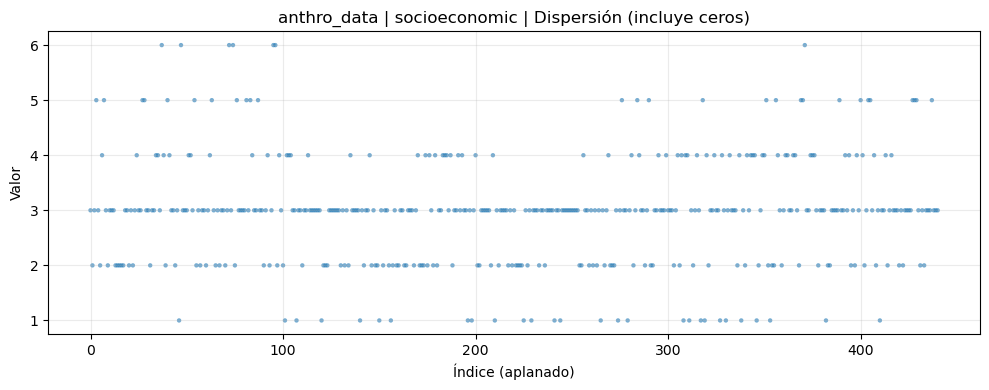

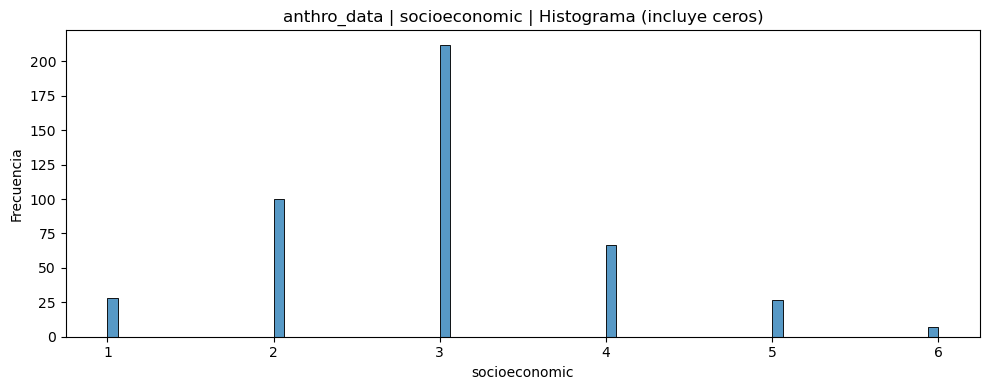

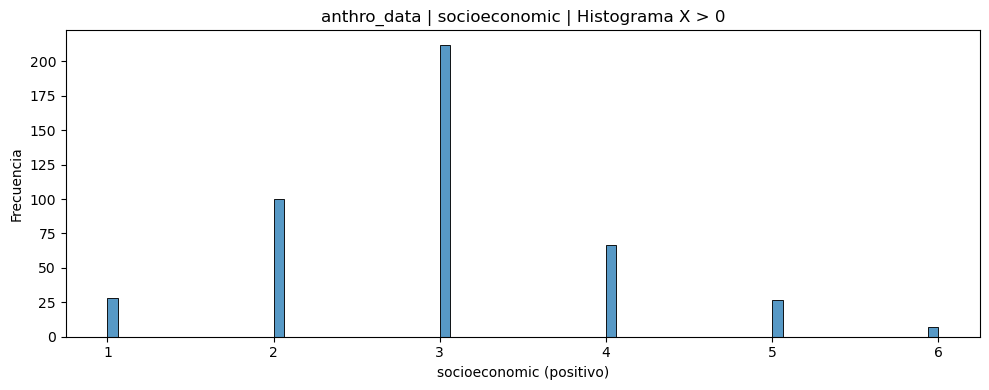


Variable: age
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 18.0
Max: 62.0
Media: 40.68480725623583
Mediana: 41.0
Desv. estándar: 11.102127991005801


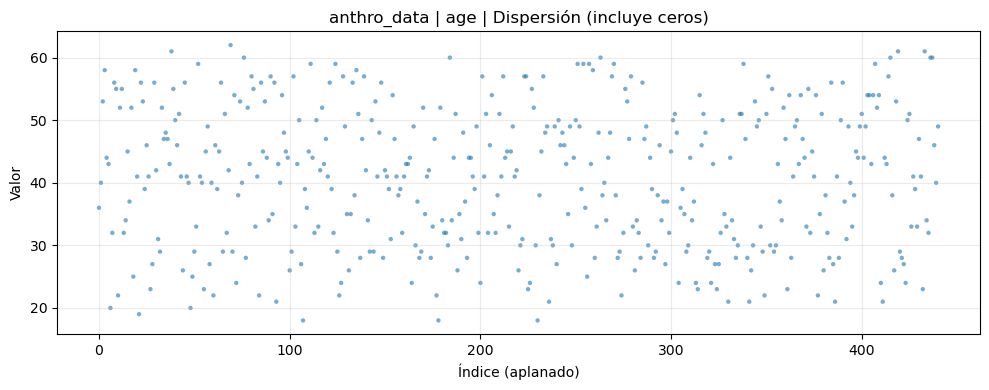

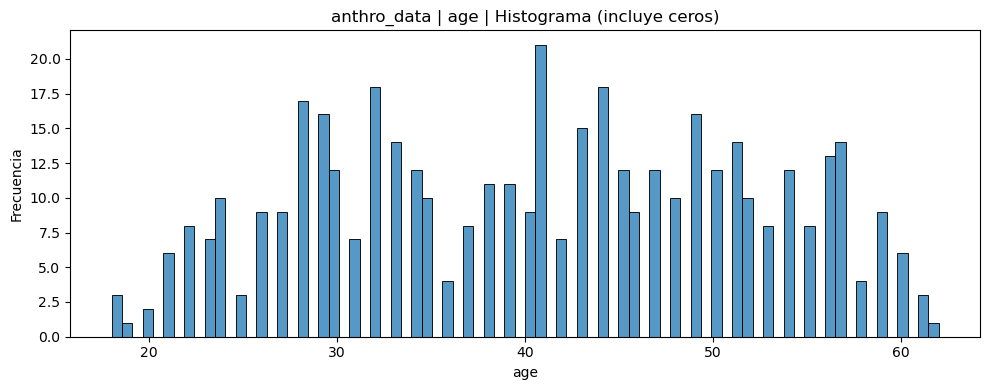

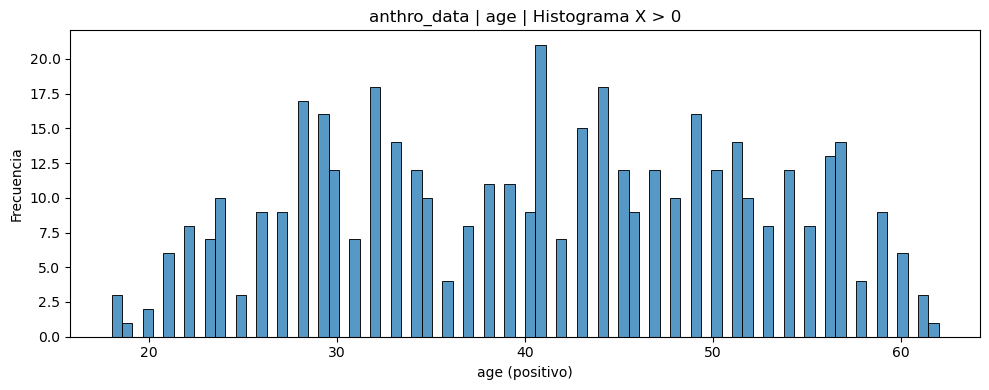


Variable: HDL
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 11.0
Max: 134.0
Media: 45.97732426303855
Mediana: 44.0
Desv. estándar: 13.607465634936514


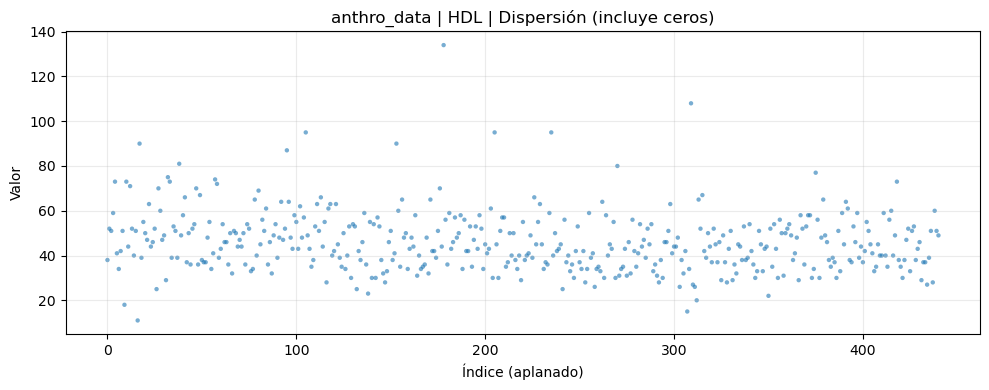

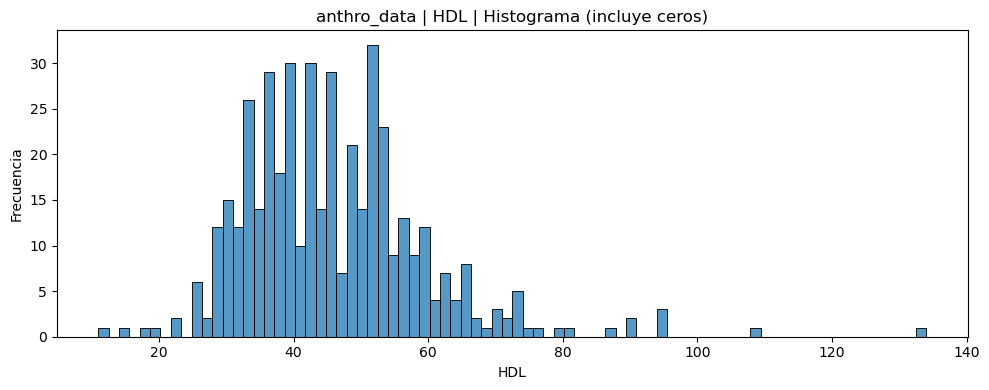

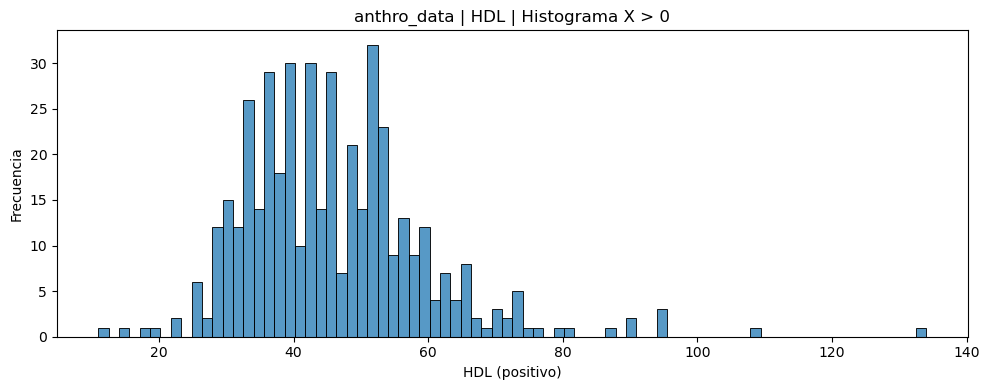


Variable: LDL
N total (finitos): 439
N positivos: 439
N ceros: 0
Min: 30.0
Max: 219.0
Media: 115.05330296127563
Mediana: 113.0
Desv. estándar: 30.430259840352726


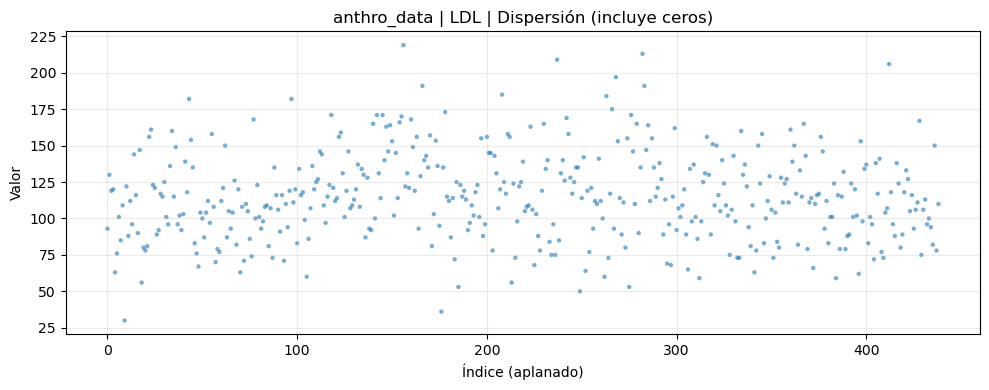

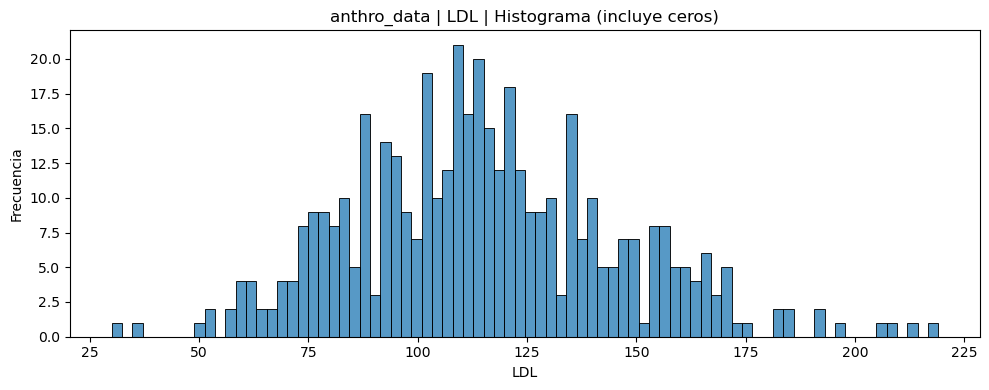

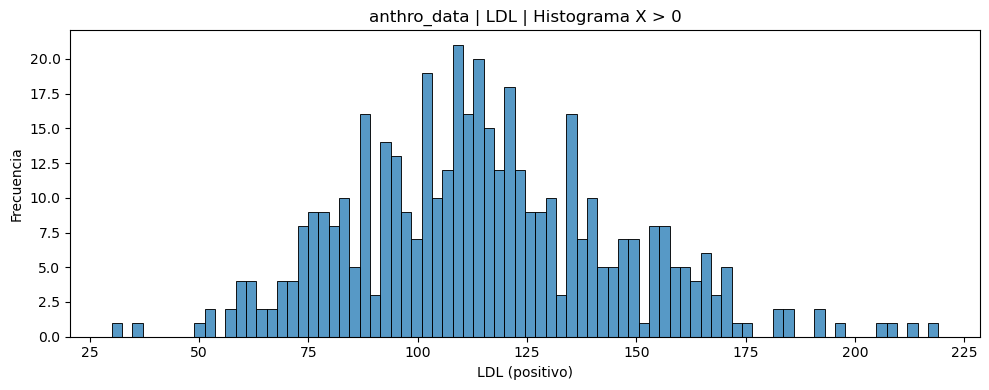


Variable: cholesterol
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 67.0
Max: 302.0
Media: 185.843537414966
Mediana: 184.0
Desv. estándar: 35.00091570495733


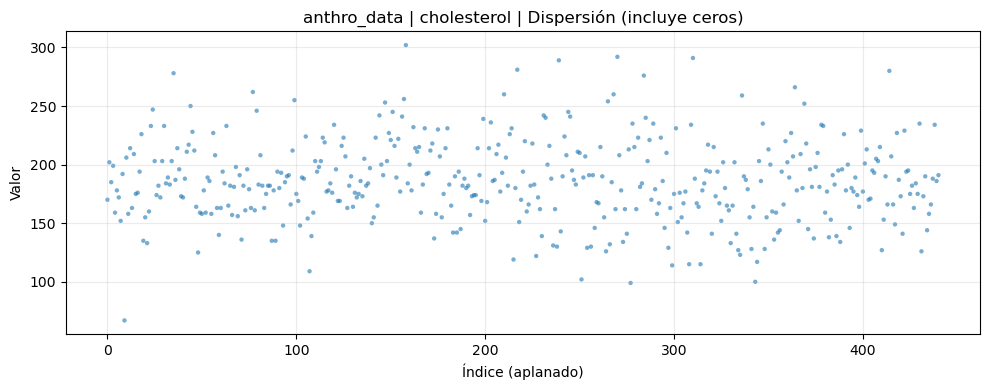

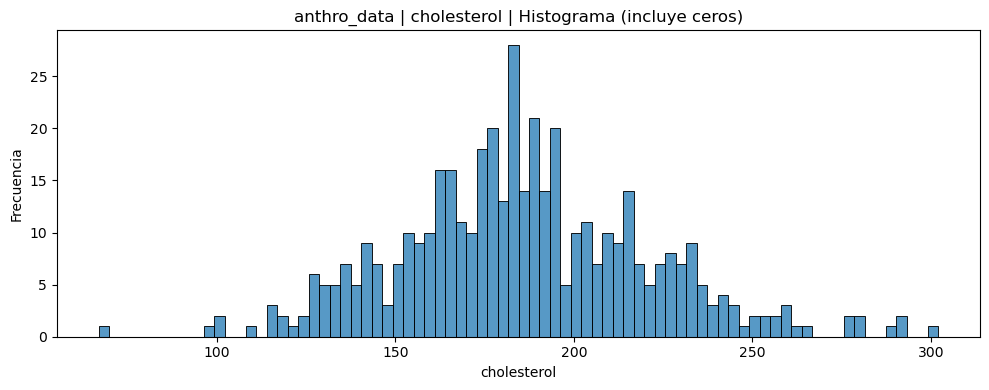

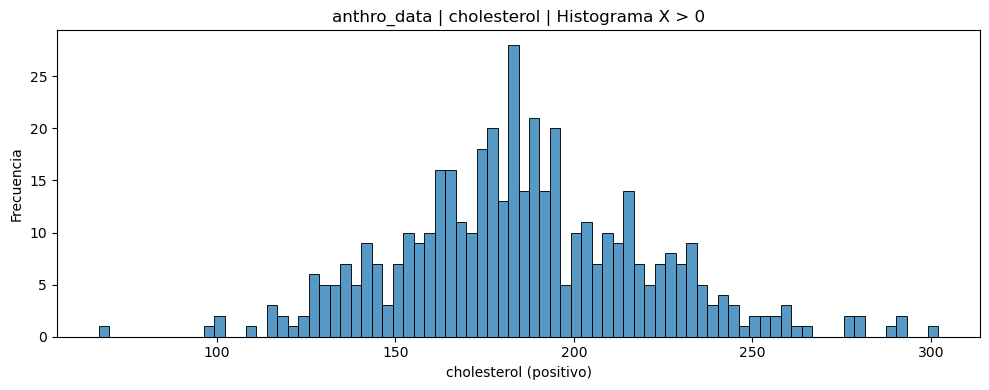


Variable: triglycerides
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 28.0
Max: 1090.0
Media: 143.41496598639455
Mediana: 118.0
Desv. estándar: 98.92992310014758


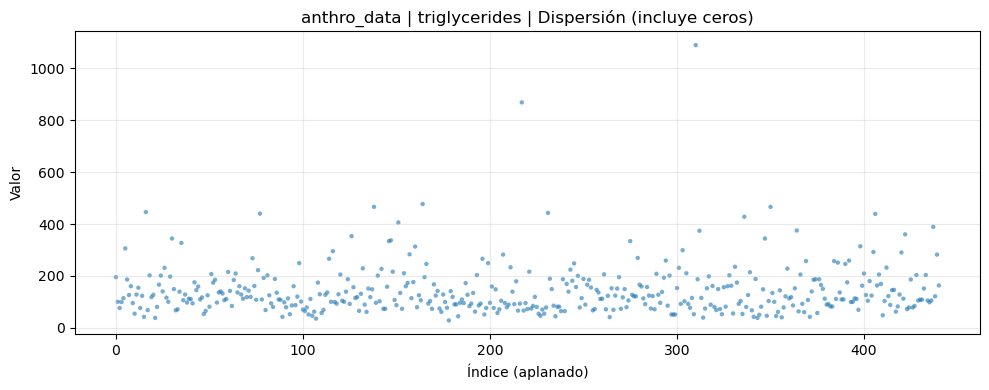

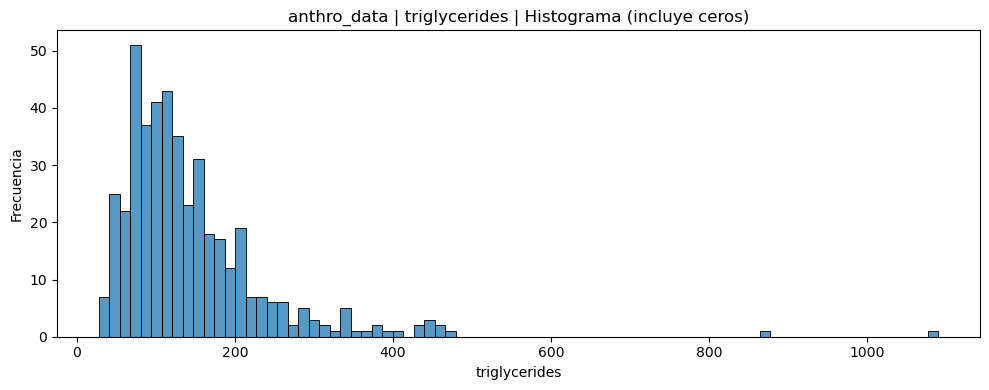

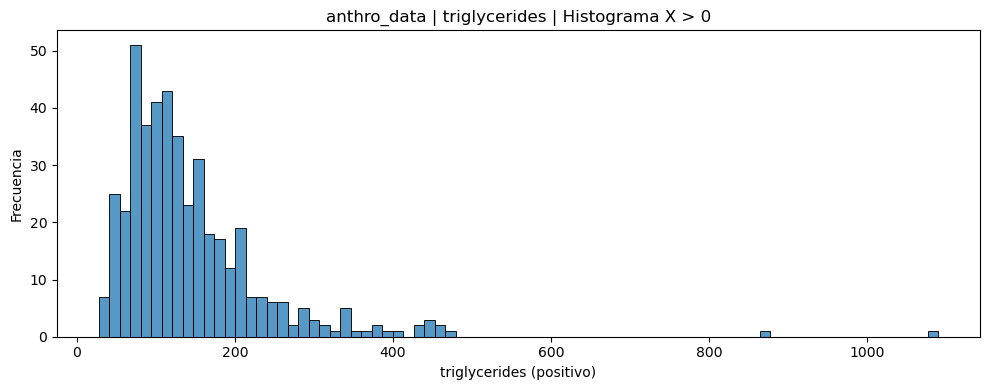


Variable: hsCRP
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 0.12
Max: 44.3
Media: 3.150680272108844
Mediana: 1.9
Desv. estándar: 4.553882907605125


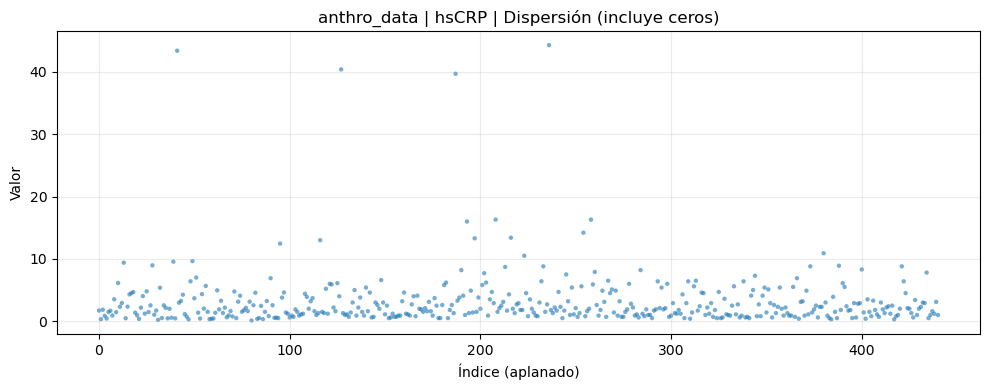

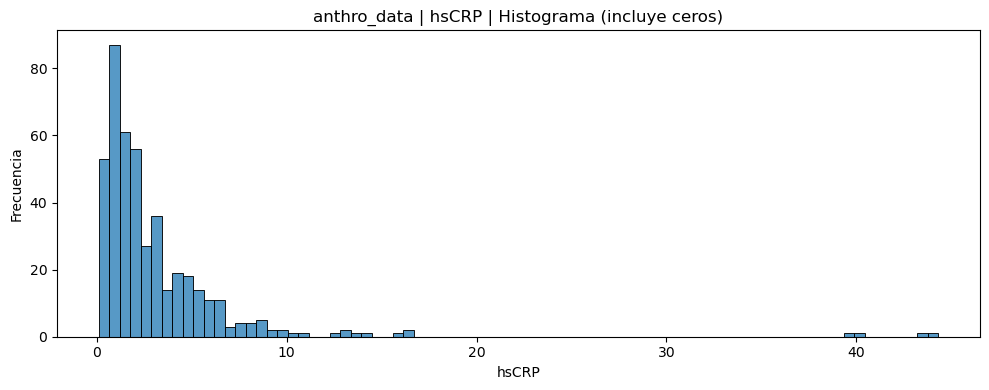

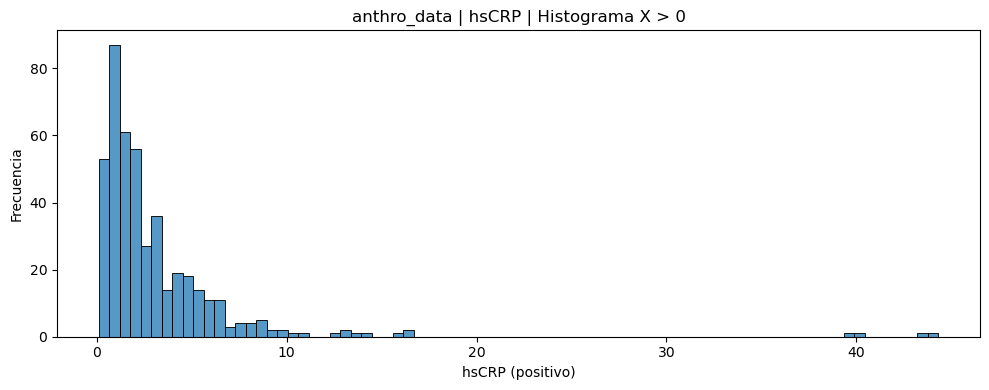


Variable: glucose
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 64.0
Max: 335.0
Media: 89.39909297052154
Mediana: 86.0
Desv. estándar: 21.27491905962534


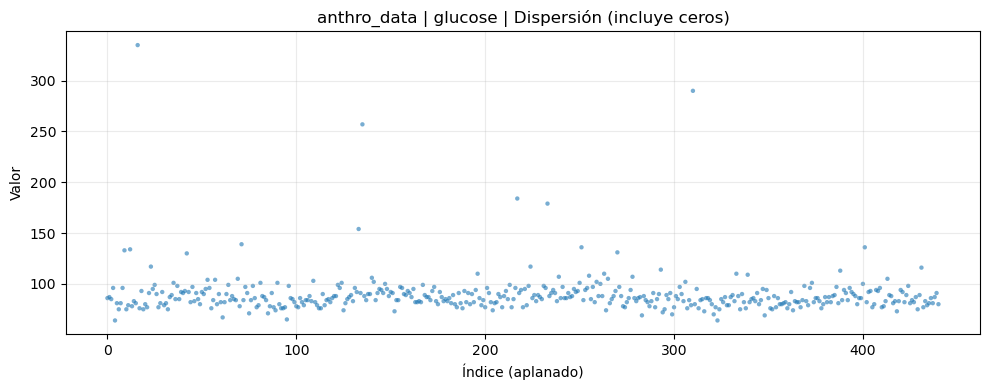

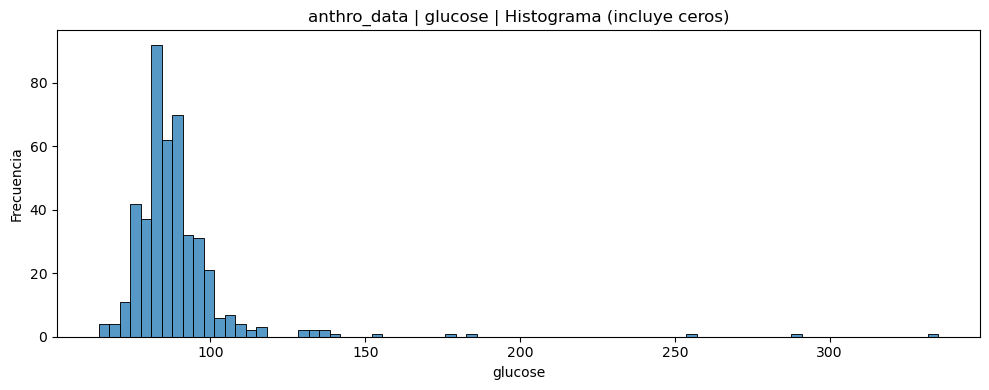

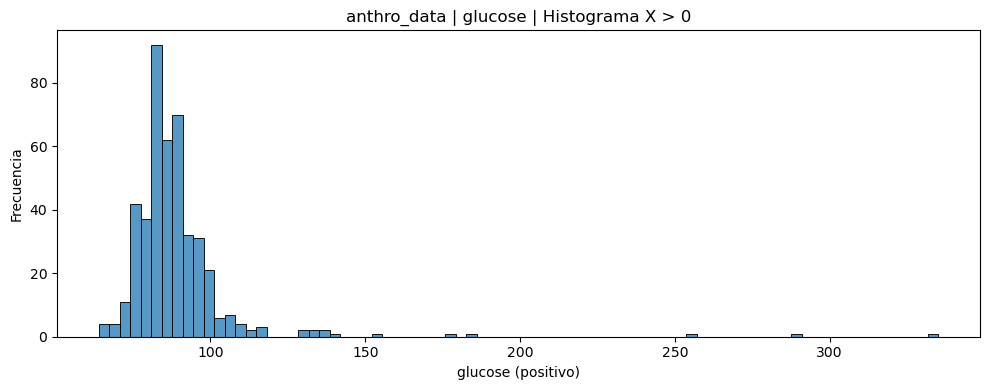


Variable: glycosylated_hg
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 4.6
Max: 10.77
Media: 5.5528571428571425
Mediana: 5.5
Desv. estándar: 0.620348509087652


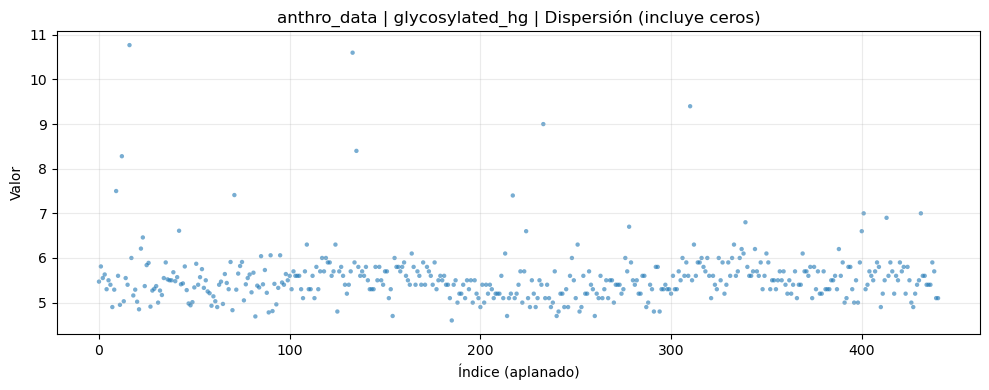

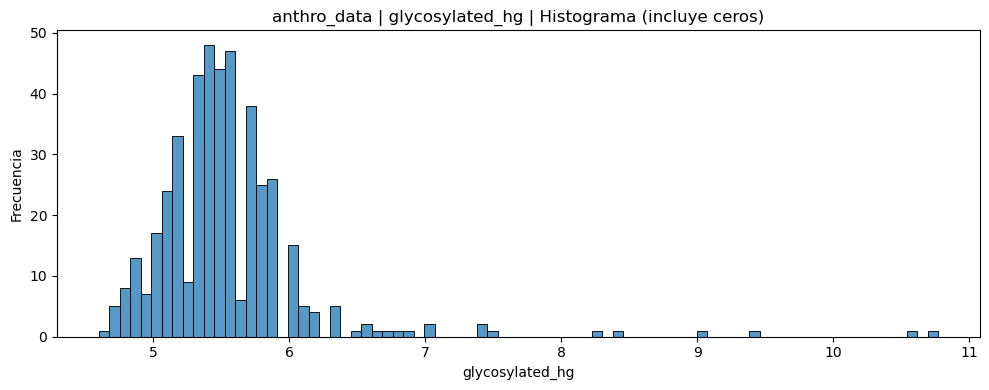

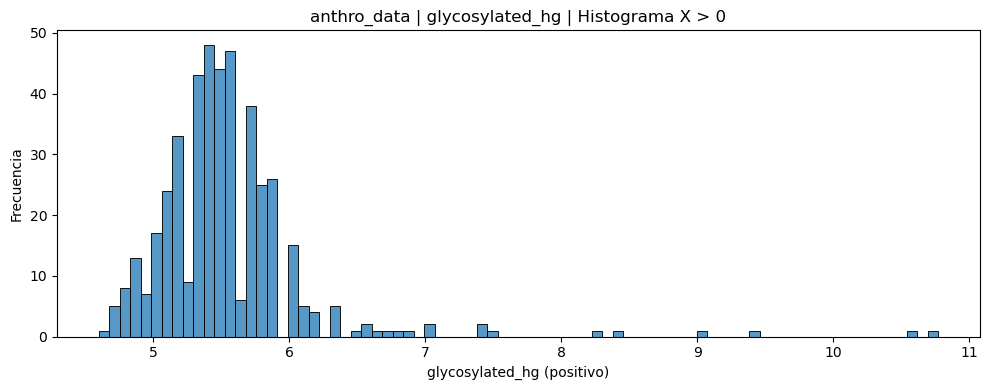


Variable: adiponectin
N total (finitos): 441
N positivos: 440
N ceros: 1
Min: 0.0
Max: 28.21
Media: 6.805079365079366
Mediana: 5.95
Desv. estándar: 4.049623445519972


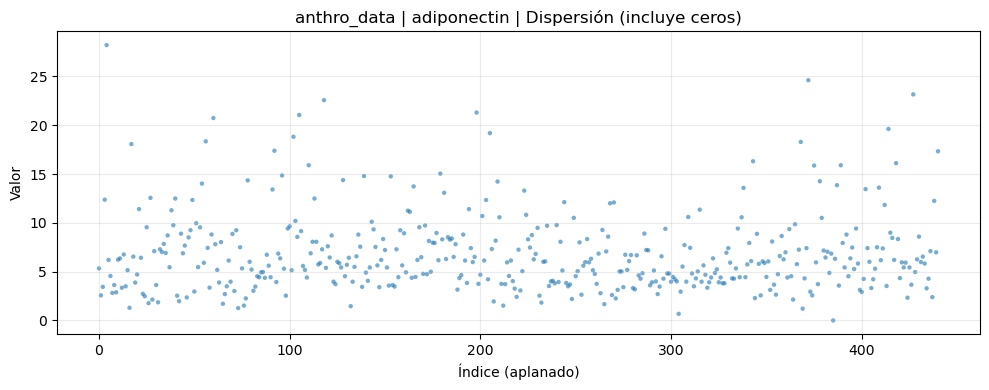

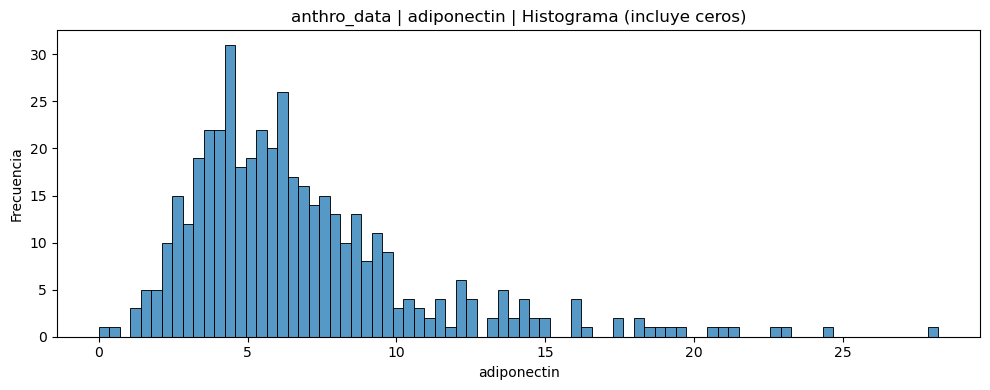

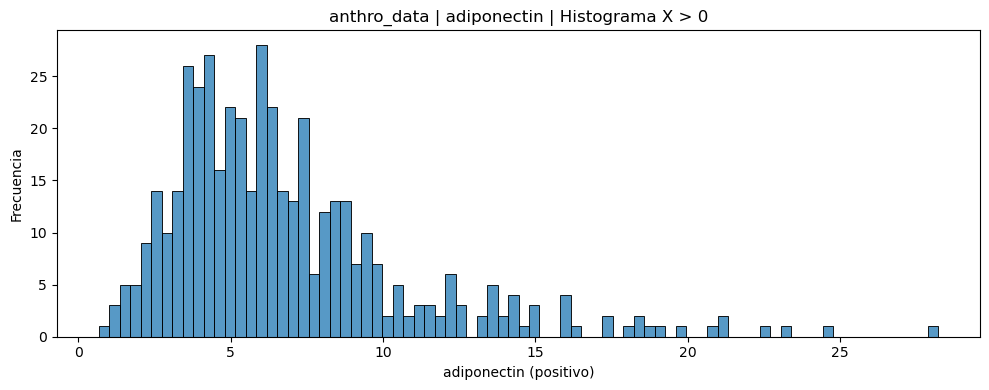


Variable: insulin
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 1.95
Max: 57.07
Media: 13.263786848072563
Mediana: 11.0
Desv. estándar: 8.530440915808475


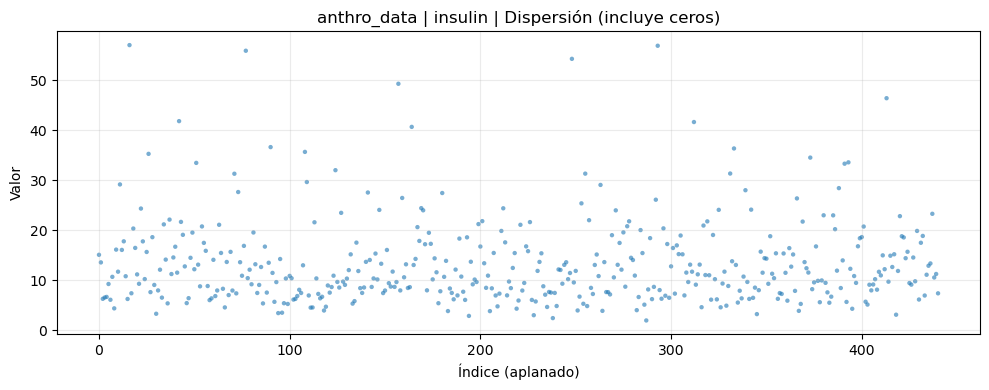

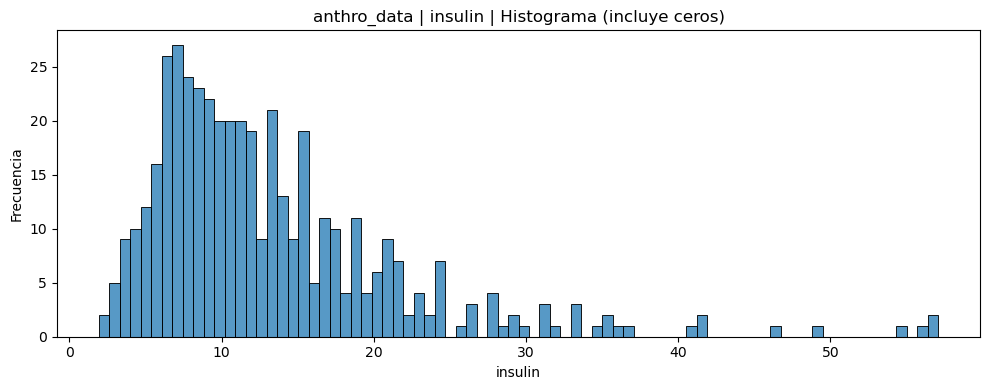

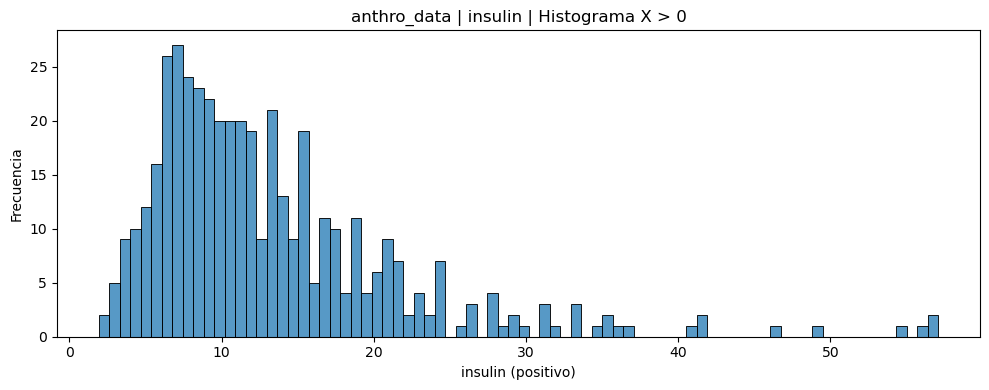


Variable: HOMA_IR
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 0.37518
Max: 47.15884333
Media: 3.1247881556938775
Mediana: 2.316496
Desv. estándar: 3.0998476832981914


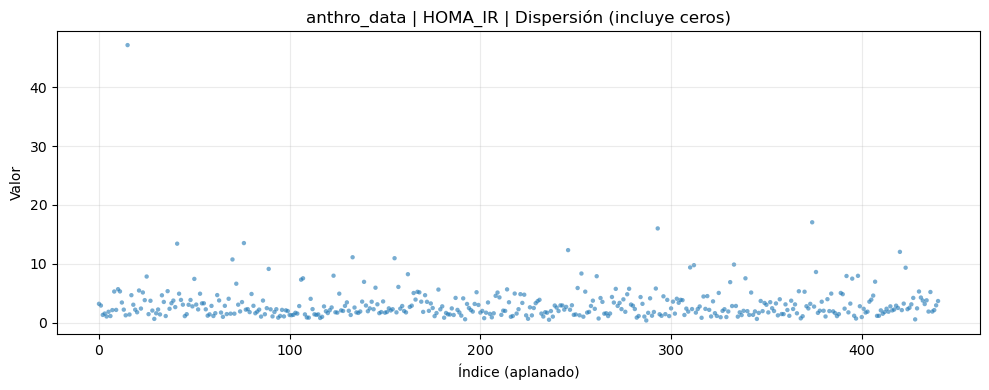

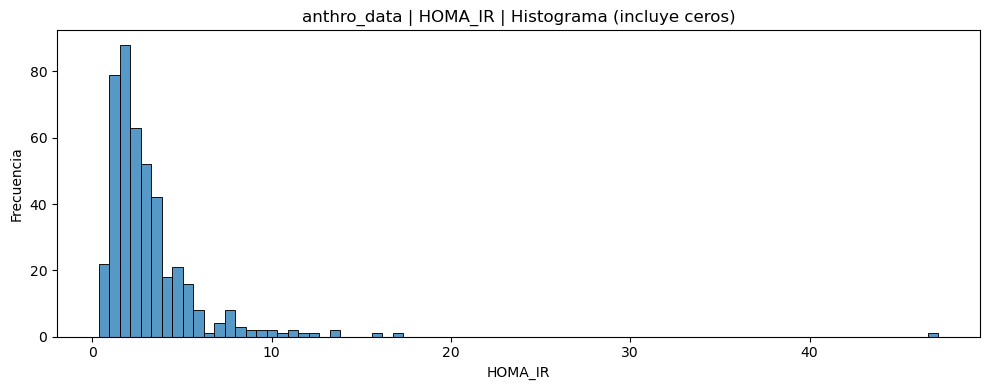

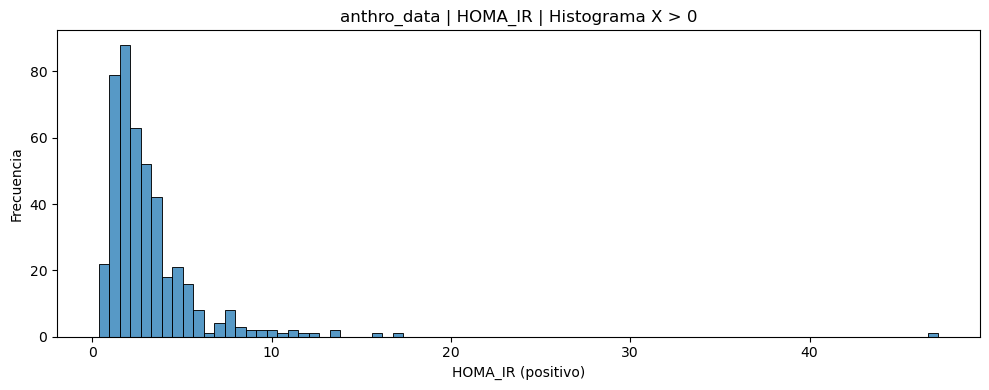


Variable: systolic_bp
N total (finitos): 440
N positivos: 440
N ceros: 0
Min: 76.0
Max: 204.0
Media: 124.3340909090909
Mediana: 122.5
Desv. estándar: 18.535436026522582


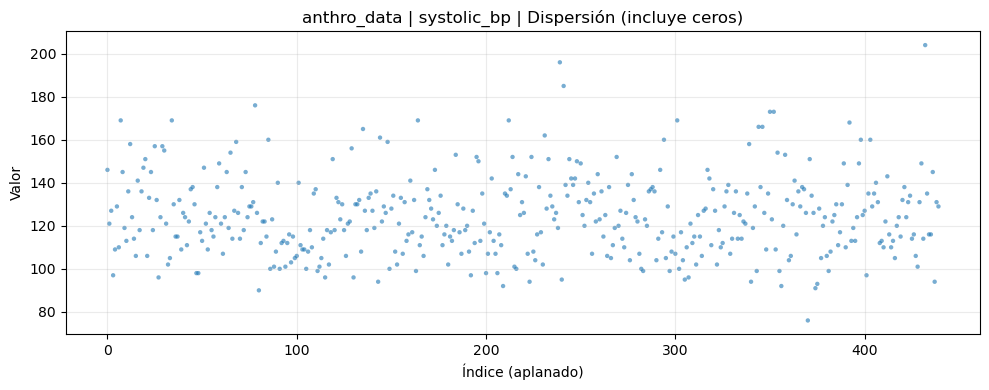

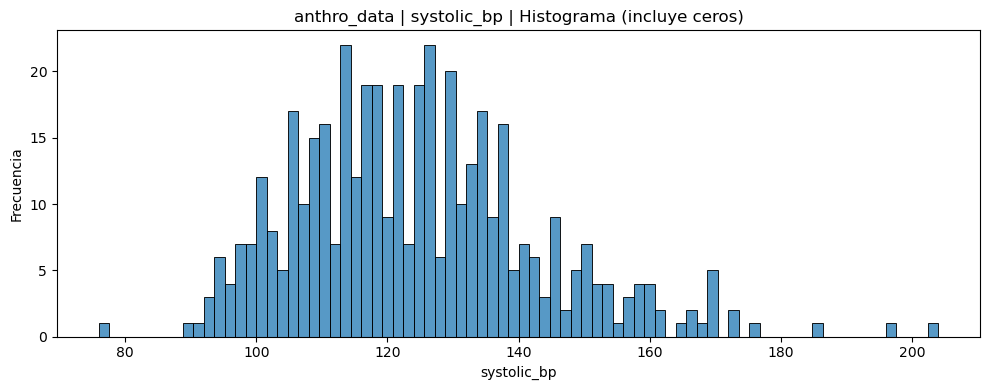

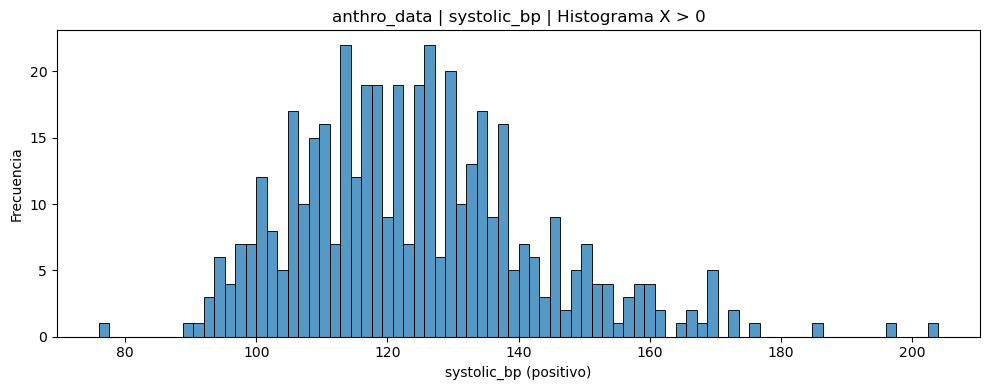


Variable: diastolic_bp
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 50.0
Max: 126.0
Media: 80.22448979591837
Mediana: 80.0
Desv. estándar: 12.264210265332293


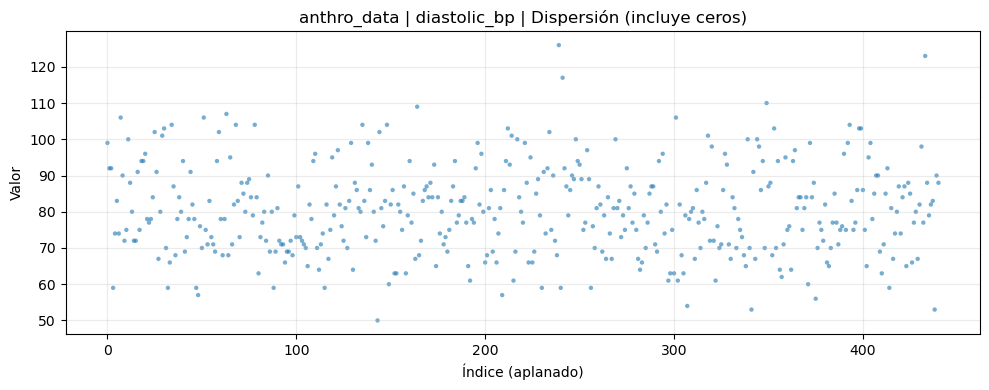

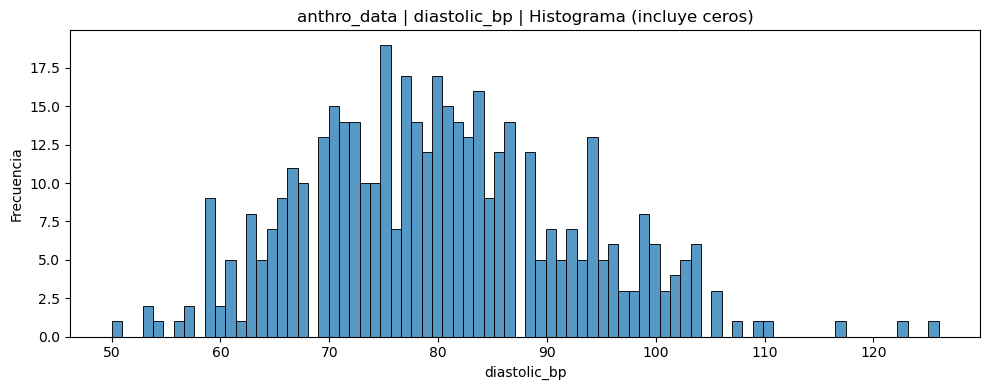

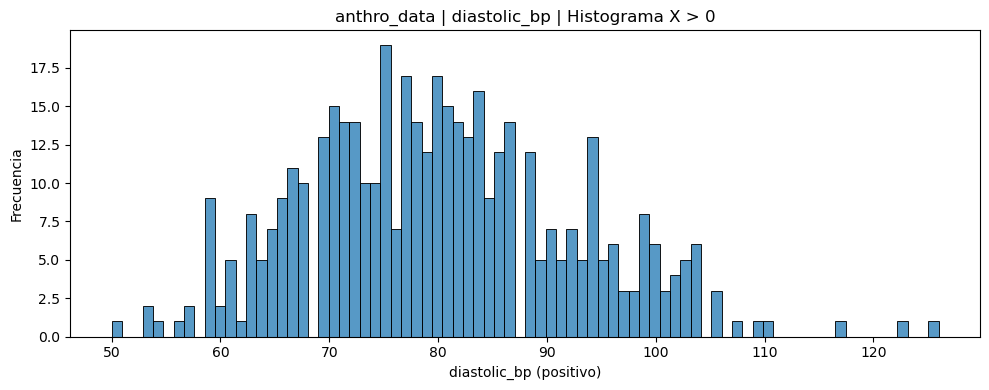


Variable: bmi
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 18.6
Max: 47.4
Media: 27.93378684807256
Mediana: 27.4
Desv. estándar: 4.998319393911708


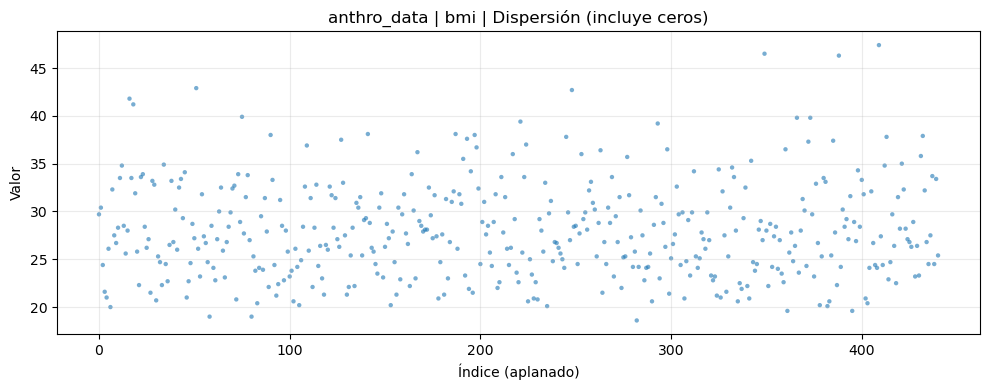

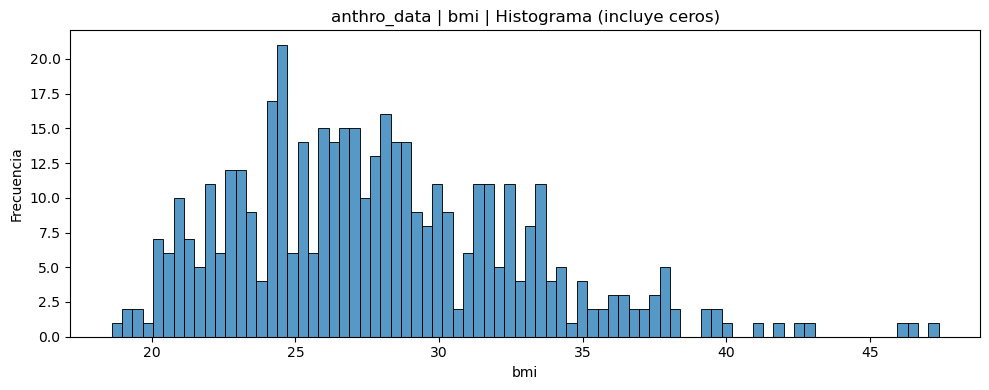

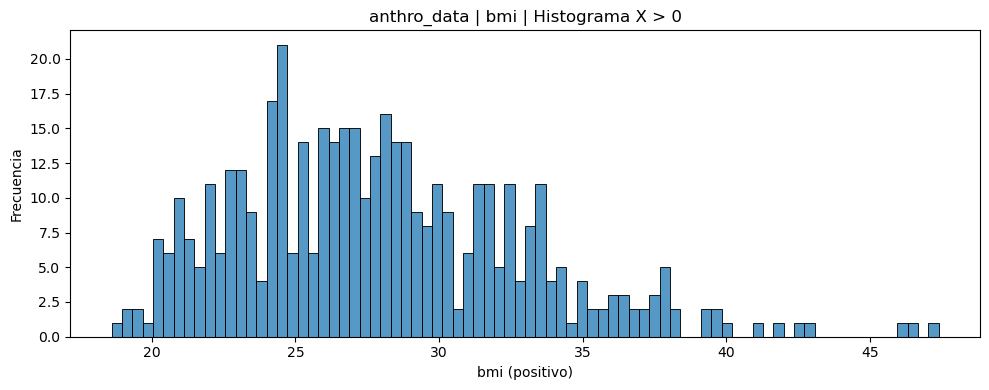


Variable: body_fat
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 18.68840957
Max: 48.67844898
Media: 37.182237669977326
Mediana: 37.57925739
Desv. estándar: 5.472760786163114


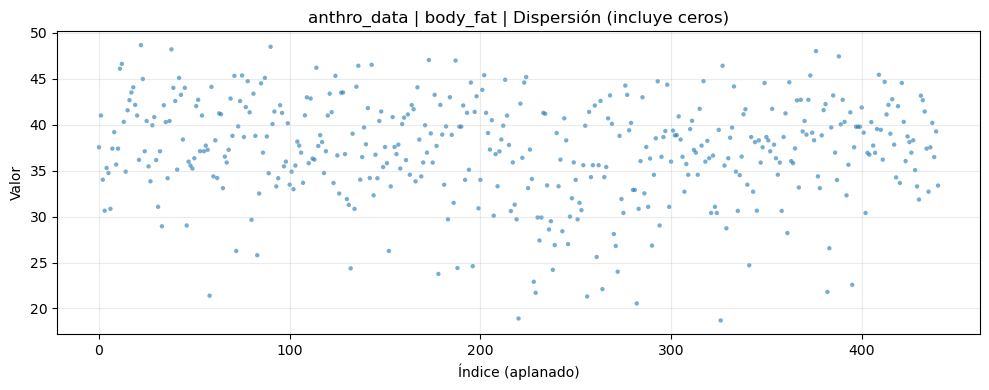

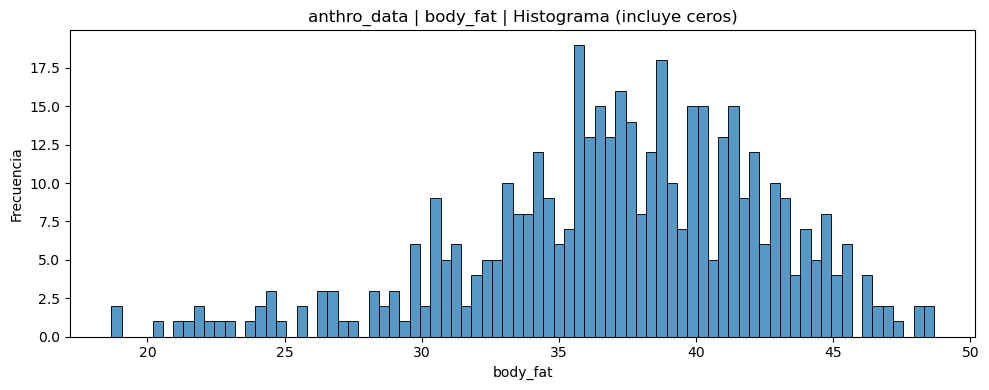

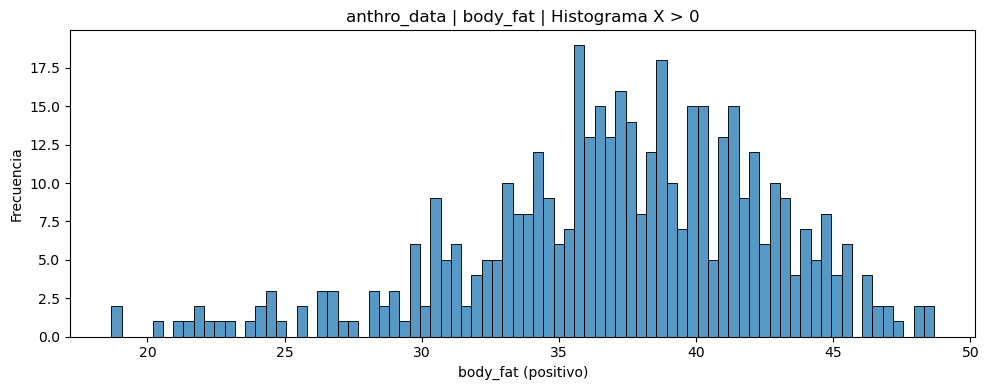


Variable: waist
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 65.2
Max: 139.7
Media: 92.7530612244898
Mediana: 92.0
Desv. estándar: 13.264544193188893


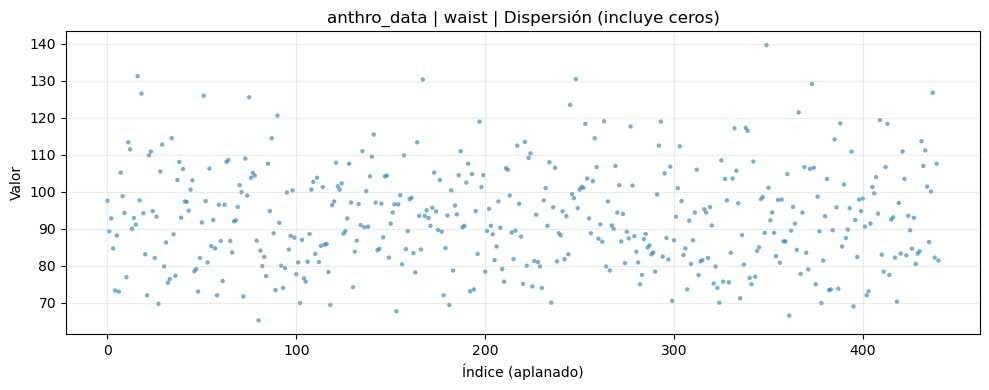

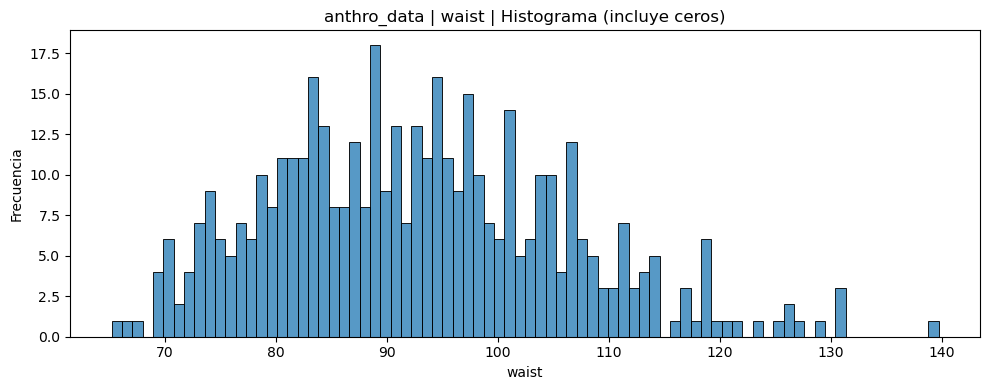

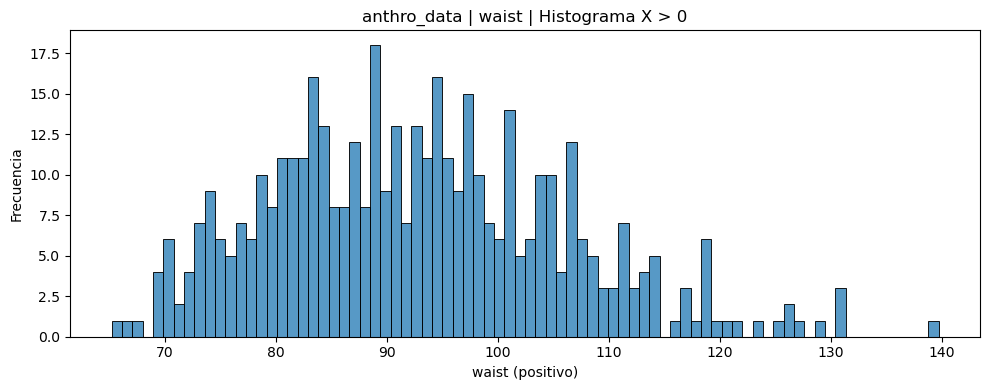


Variable: fiber
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 7.0
Max: 44.0
Media: 17.705215419501133
Mediana: 17.0
Desv. estándar: 5.078850533100957


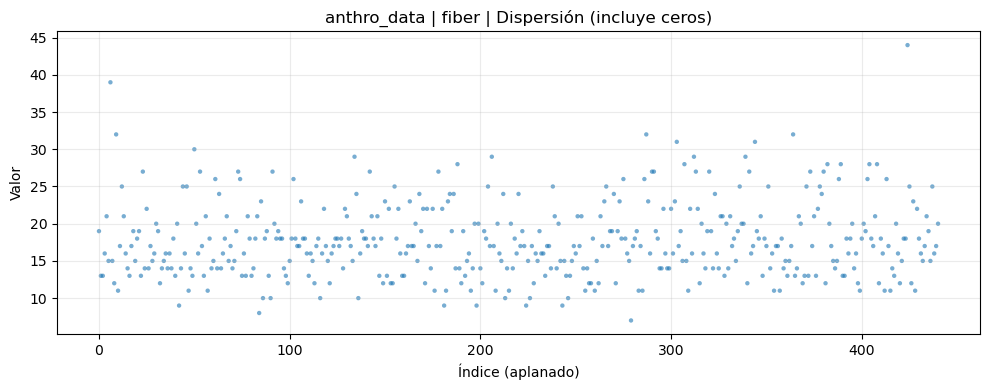

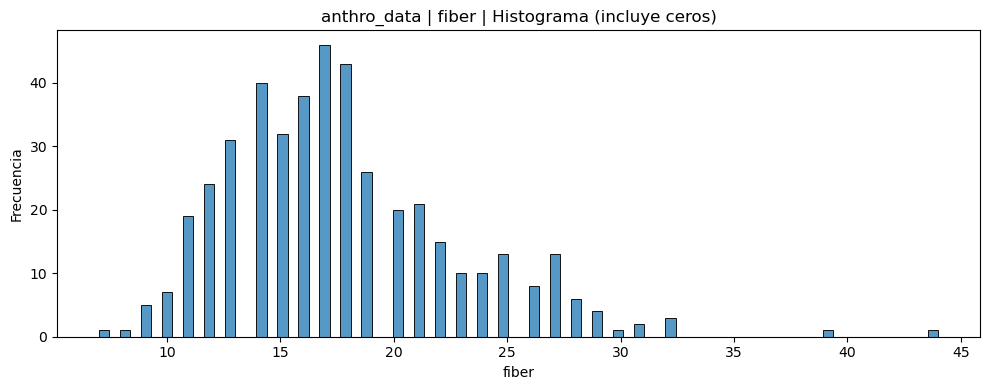

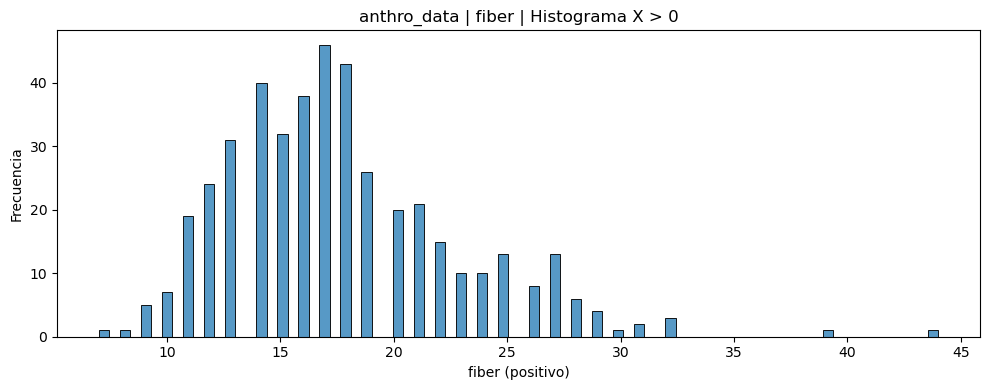


Variable: per_protein
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 11.95
Max: 21.11
Media: 15.725374149659862
Mediana: 15.62
Desv. estándar: 1.4436958280000627


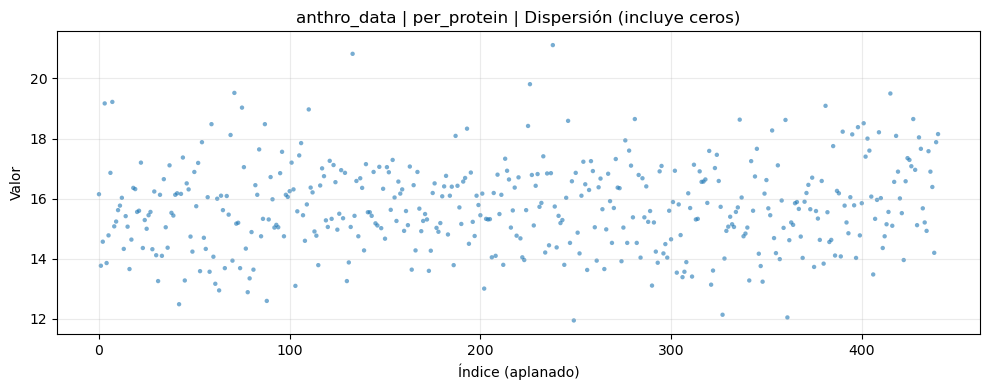

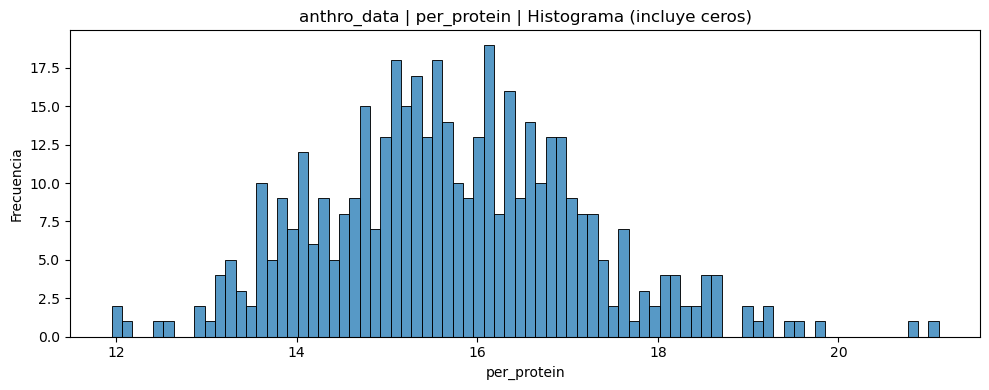

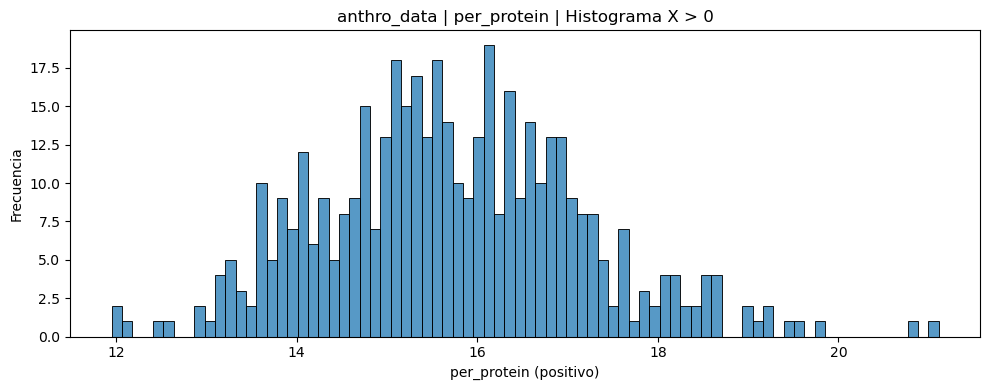


Variable: per_animal_protein
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 39.41
Max: 74.48
Media: 62.78646258503401
Mediana: 63.22
Desv. estándar: 5.346240455096514


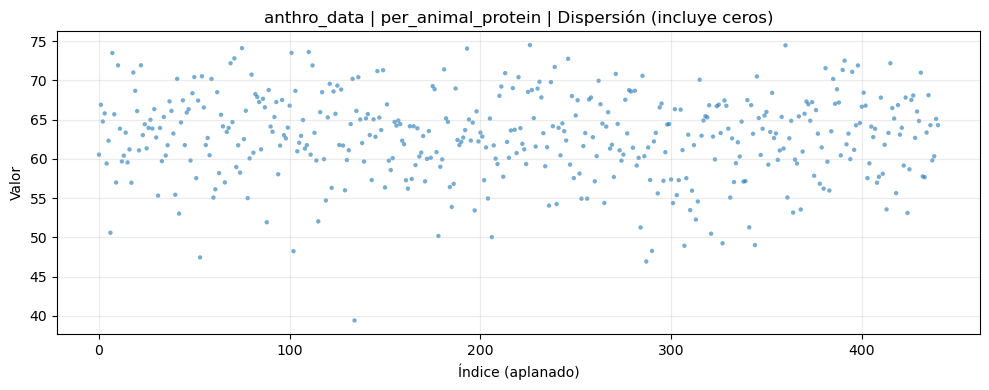

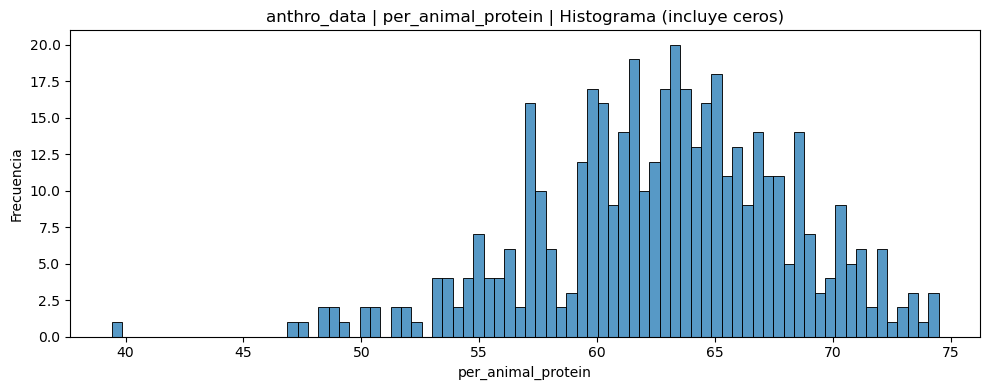

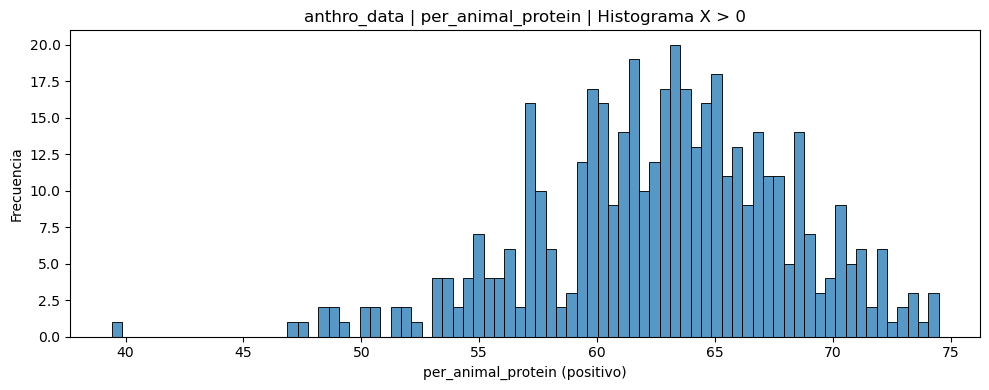


Variable: per_total_fat
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 21.51
Max: 36.83
Media: 28.698684807256235
Mediana: 28.72
Desv. estándar: 2.4539391510887


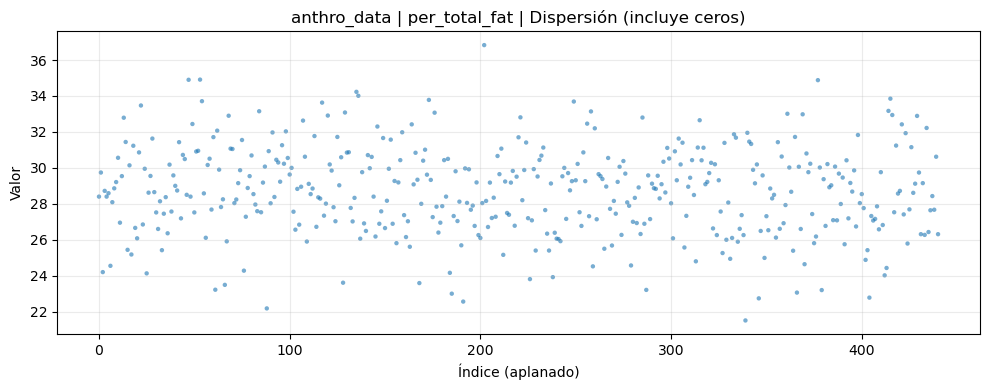

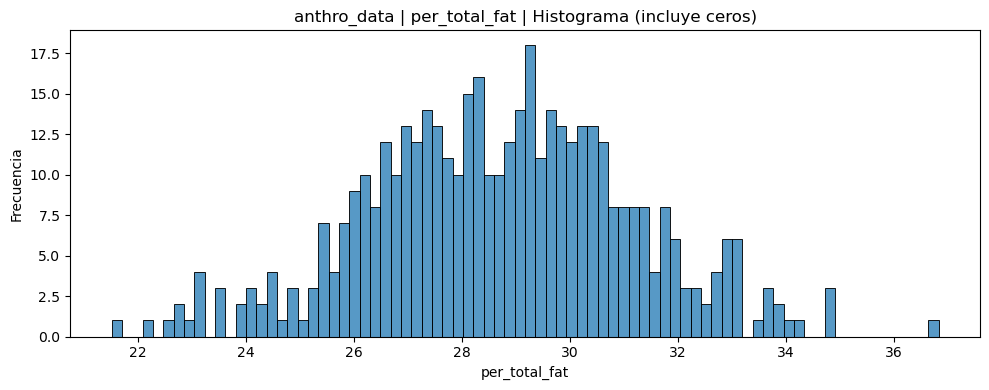

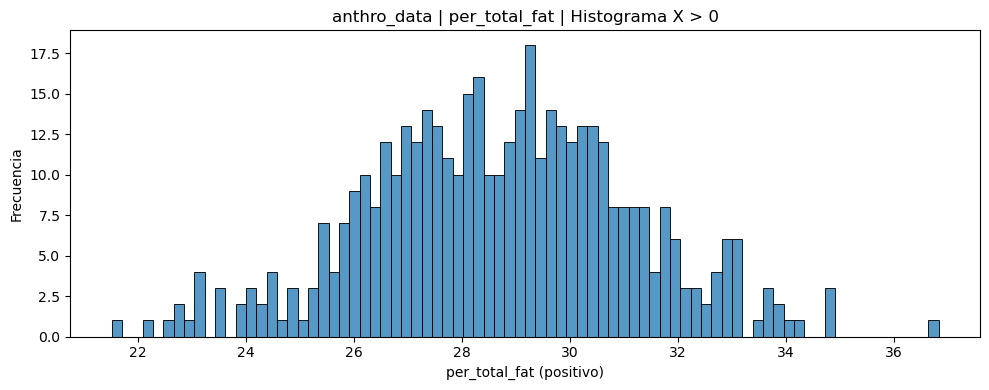


Variable: per_saturated_fat
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 7.46
Max: 16.06
Media: 11.303174603174606
Mediana: 11.37
Desv. estándar: 1.35945205836392


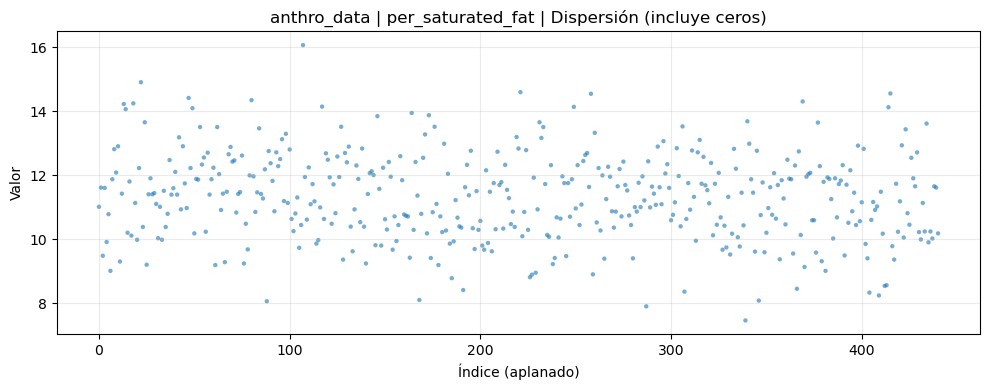

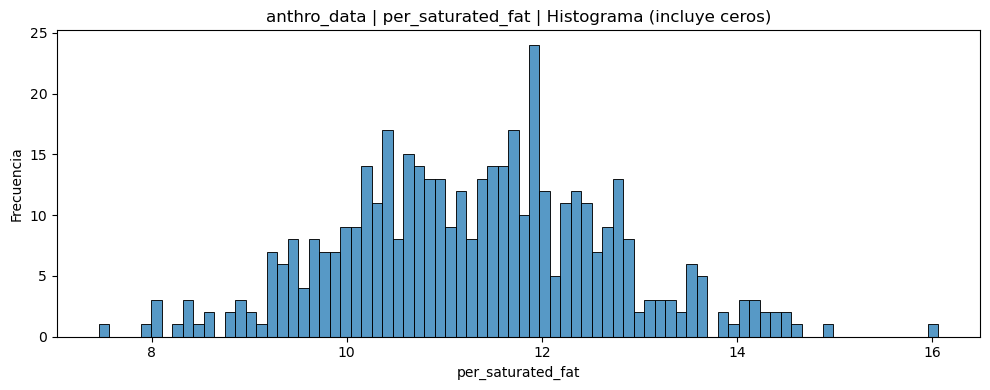

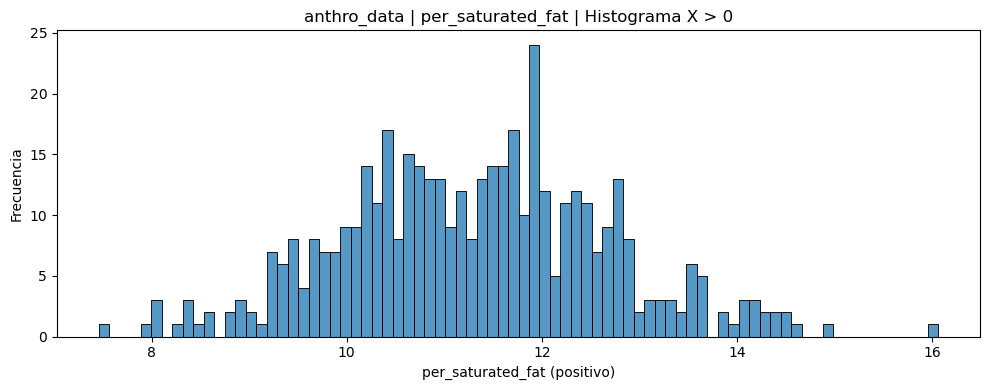


Variable: per_monoinsaturated_fat
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 6.85
Max: 12.55
Media: 9.907233560090702
Mediana: 9.91
Desv. estándar: 0.9788365368028777


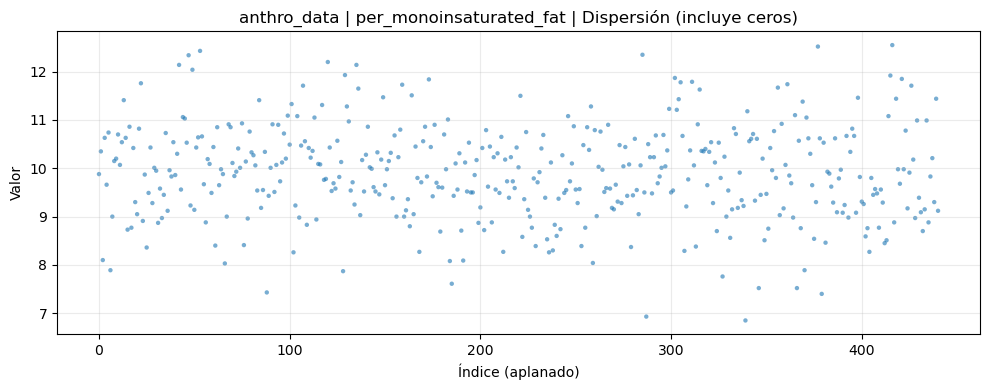

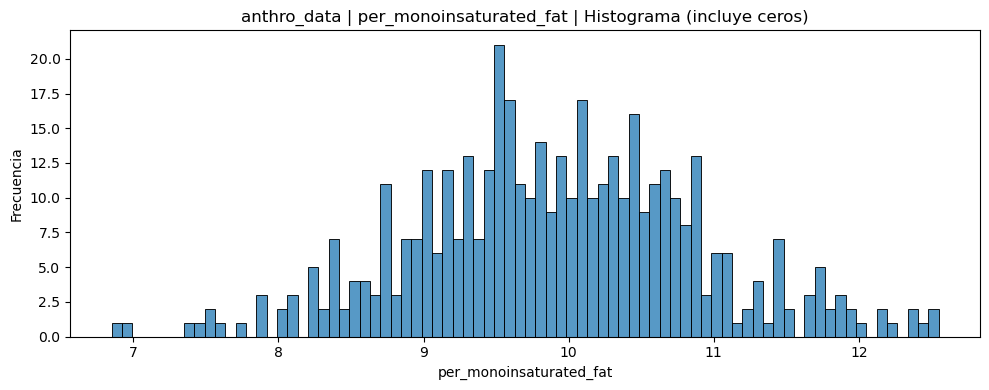

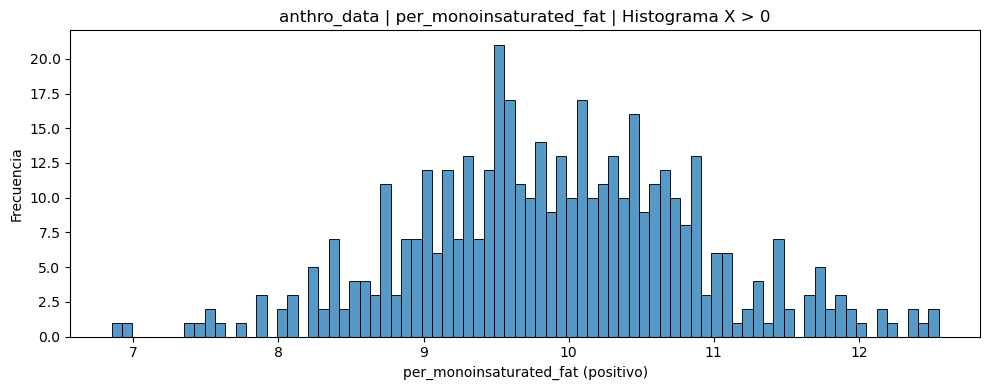


Variable: per_polyunsaturated_fat
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 3.48
Max: 7.86
Media: 5.524353741496598
Mediana: 5.48
Desv. estándar: 0.7816047606401125


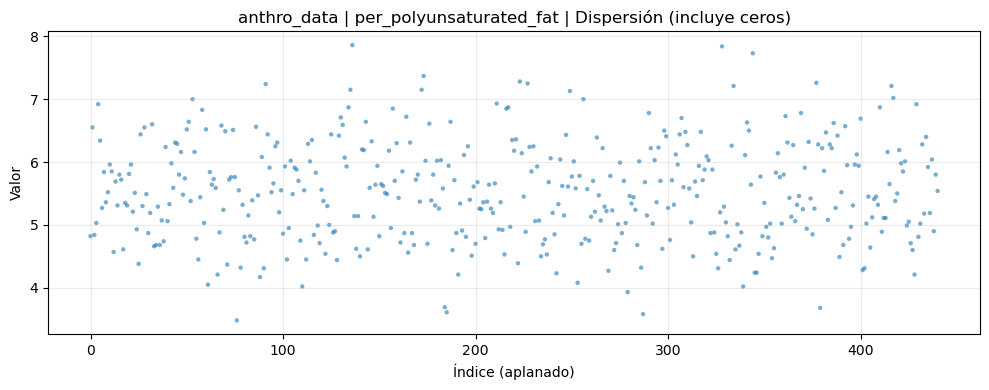

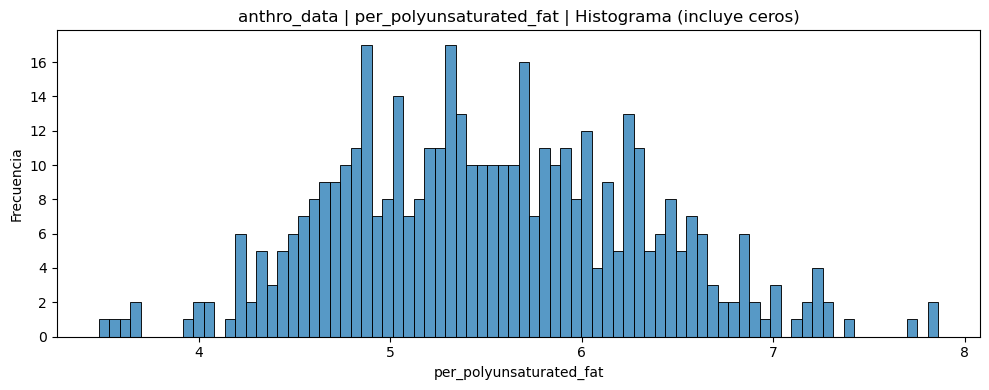

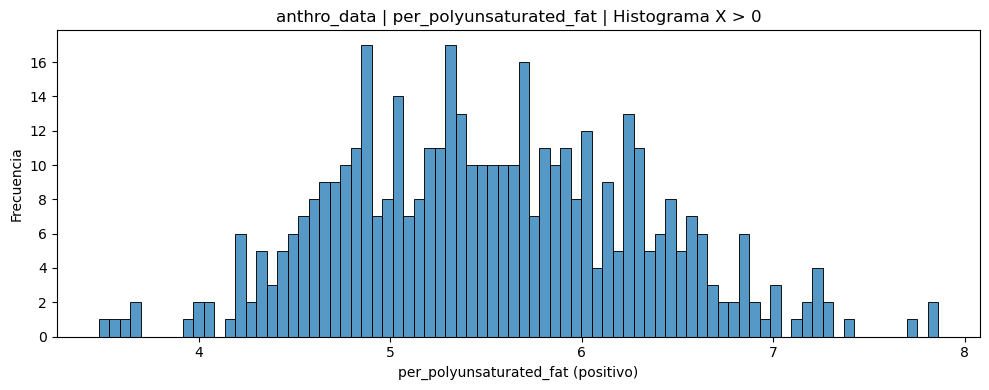


Variable: per_carbohydrates
N total (finitos): 441
N positivos: 441
N ceros: 0
Min: 45.89
Max: 64.87
Media: 55.416825396825395
Mediana: 55.27
Desv. estándar: 3.0312008404844333


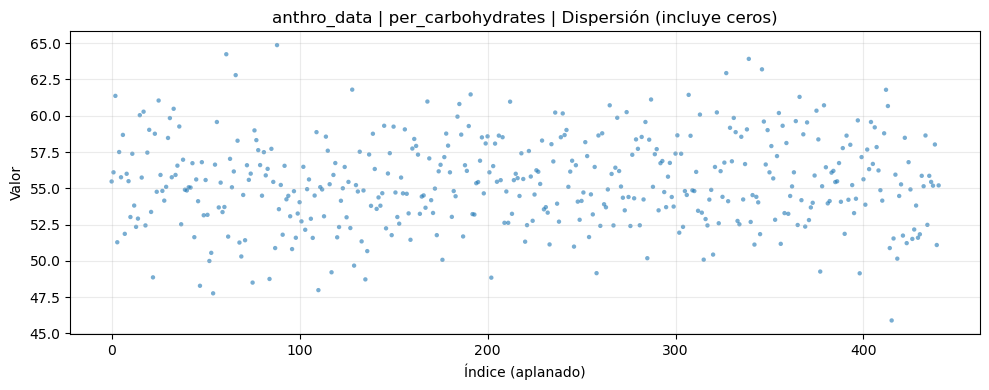

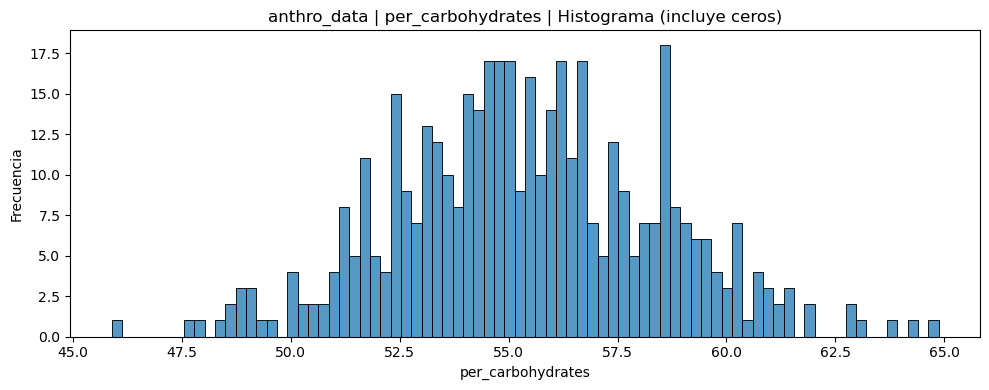

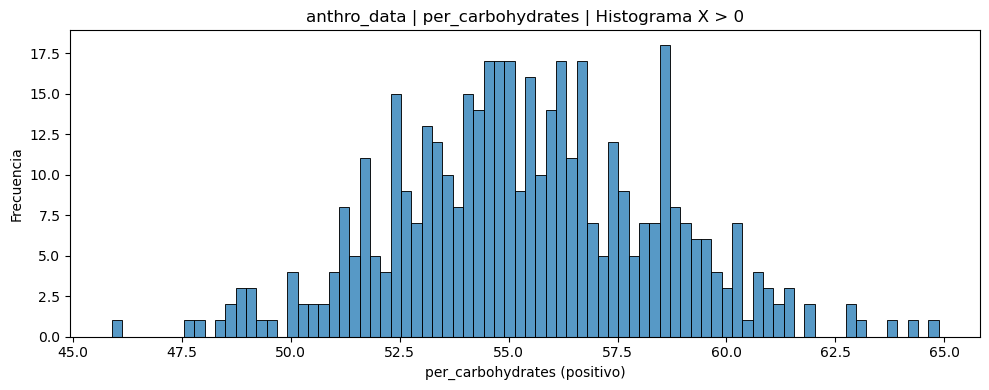


=== MATRIZ COMPLETA ===
N total (finitos): 11022
N positivos: 11021
N ceros: 1
Min: 0.0
Max: 1090.0
Media: 48.970515186819185
Mediana: 29.2
Desv. estándar: 54.87466576889858


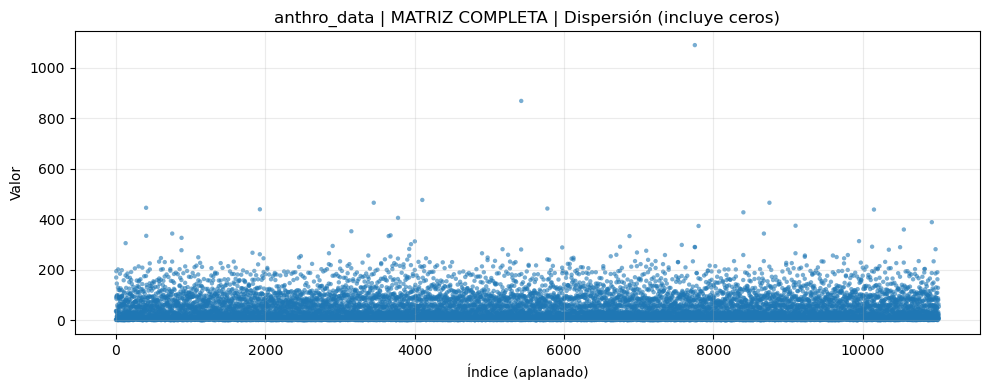

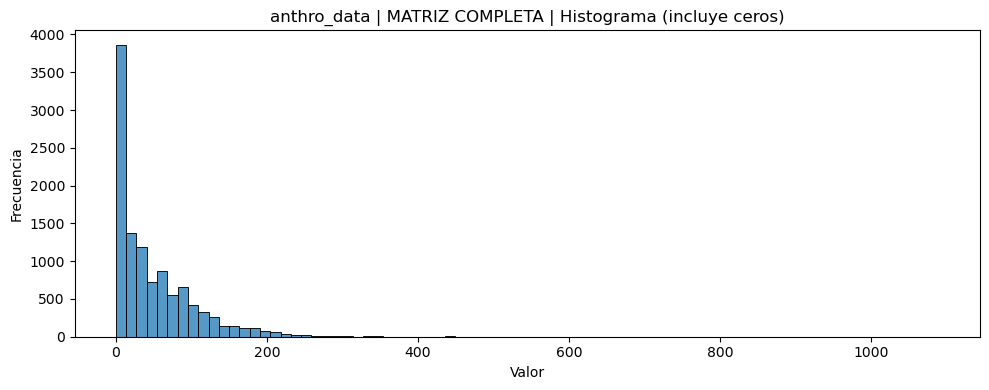

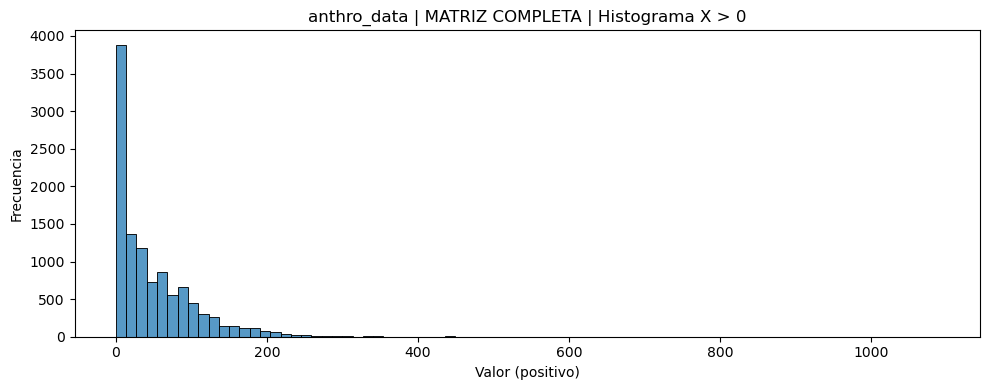

In [12]:
result = distribution_plots_from_loaded(
    dfs=dfs,
    df_name="anthro_data",
    analysis_mode="both",
    numeric_cols=None,
    bins=80,
    plot_positive_hist=True,
    verbose=True
)

In [13]:
result["summary_full_matrix"]
result["summary_by_column"]

,variable,n_total_finitos,n_positivos,n_ceros,min,max,mean,median,std,status
0,socioeconomic,441,441,0,1.00000,6.000000,2.968254,3.000000,1.010800,OK
1,age,441,441,0,18.00000,62.000000,40.684807,41.000000,11.102128,OK
2,HDL,441,441,0,11.00000,134.000000,45.977324,44.000000,13.607466,OK
3,LDL,439,439,0,30.00000,219.000000,115.053303,113.000000,30.430260,OK
4,cholesterol,441,441,0,67.00000,302.000000,185.843537,184.000000,35.000916,OK
5,triglycerides,441,441,0,28.00000,1090.000000,143.414966,118.000000,98.929923,OK
6,hsCRP,441,441,0,0.12000,44.300000,3.150680,1.900000,4.553883,OK
7,glucose,441,441,0,64.00000,335.000000,89.399093,86.000000,21.274919,OK
8,glycosylated_hg,441,441,0,4.60000,10.770000,5.552857,5.500000,0.620349,OK
9,adiponectin,441,440,1,0.00000,28.210000,6.805079,5.950000,4.049623,OK


In [29]:
def _prepare_numeric_vector(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return values

def _run_shapiro_test(values, alpha):
    values = _prepare_numeric_vector(values)

    if len(values) < 3:
        return {
            "shapiro_statistic": np.nan,
            "shapiro_p_value": np.nan,
            "shapiro_reject_h0": np.nan,
            "shapiro_decision": "No se puede ejecutar (n < 3)"
        }

    if len(np.unique(values)) < 2:
        return {
            "shapiro_statistic": np.nan,
            "shapiro_p_value": np.nan,
            "shapiro_reject_h0": np.nan,
            "shapiro_decision": "No se puede ejecutar (varianza cero / valores constantes)"
        }

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            stat, pval = shapiro(values)

        reject = bool(pval < alpha)

        return {
            "shapiro_statistic": float(stat),
            "shapiro_p_value": float(pval),
            "shapiro_reject_h0": reject,
            "shapiro_decision": "Se rechaza H0 de normalidad" if reject else "No se rechaza H0 de normalidad"
        }

    except Exception as e:
        return {
            "shapiro_statistic": np.nan,
            "shapiro_p_value": np.nan,
            "shapiro_reject_h0": np.nan,
            "shapiro_decision": f"Error: {e}"
        }

def _run_anderson_distribution_test(values, dist_code, alpha, prefix, null_label):
    values = _prepare_numeric_vector(values)

    if len(values) < 3:
        return {
            f"{prefix}_statistic": np.nan,
            f"{prefix}_critical_value": np.nan,
            f"{prefix}_level_used_pct": np.nan,
            f"{prefix}_reject_h0": np.nan,
            f"{prefix}_decision": "No se puede ejecutar (n < 3)"
        }

    if len(np.unique(values)) < 2:
        return {
            f"{prefix}_statistic": np.nan,
            f"{prefix}_critical_value": np.nan,
            f"{prefix}_level_used_pct": np.nan,
            f"{prefix}_reject_h0": np.nan,
            f"{prefix}_decision": "No se puede ejecutar (varianza cero / valores constantes)"
        }

    try:
        ad = anderson(values, dist=dist_code)

        alpha_pct = 100 * alpha
        levels = np.asarray(ad.significance_level, dtype=float)
        crits = np.asarray(ad.critical_values, dtype=float)

        idx_near = int(np.argmin(np.abs(levels - alpha_pct)))
        level_used = float(levels[idx_near])
        crit_used = float(crits[idx_near])

        reject = bool(ad.statistic > crit_used)

        return {
            f"{prefix}_statistic": float(ad.statistic),
            f"{prefix}_critical_value": crit_used,
            f"{prefix}_level_used_pct": level_used,
            f"{prefix}_reject_h0": reject,
            f"{prefix}_decision": f"Se rechaza H0 de {null_label}" if reject else f"No se rechaza H0 de {null_label}"
        }

    except Exception as e:
        return {
            f"{prefix}_statistic": np.nan,
            f"{prefix}_critical_value": np.nan,
            f"{prefix}_level_used_pct": np.nan,
            f"{prefix}_reject_h0": np.nan,
            f"{prefix}_decision": f"Error: {e}"
        }

def _run_lognormal_test(values_pos, alpha):
    values_pos = _prepare_numeric_vector(values_pos)
    values_pos = values_pos[values_pos > 0]

    if len(values_pos) < 3:
        return {
            "ad_lognormal_statistic": np.nan,
            "ad_lognormal_critical_value": np.nan,
            "ad_lognormal_level_used_pct": np.nan,
            "ad_lognormal_reject_h0": np.nan,
            "ad_lognormal_decision": "No se puede ejecutar (n < 3 o sin positivos)"
        }

    log_vals = np.log(values_pos)
    return _run_anderson_distribution_test(
        values=log_vals,
        dist_code="norm",
        alpha=alpha,
        prefix="ad_lognormal",
        null_label="lognormalidad"
    )

def _run_gamma_gof(values_pos, alpha):
    values_pos = _prepare_numeric_vector(values_pos)
    values_pos = values_pos[values_pos > 0]

    if len(values_pos) < 3:
        return {
            "gamma_shape": np.nan,
            "gamma_loc": np.nan,
            "gamma_scale": np.nan,
            "gamma_ks_statistic": np.nan,
            "gamma_ks_p_value": np.nan,
            "gamma_ks_reject_h0": np.nan,
            "gamma_ks_decision": "No se puede ejecutar (n < 3 o sin positivos)",
            "gamma_cvm_statistic": np.nan,
            "gamma_cvm_p_value": np.nan,
            "gamma_cvm_reject_h0": np.nan,
            "gamma_cvm_decision": "No se puede ejecutar (n < 3 o sin positivos)"
        }

    try:
        a, loc, scale = stats.gamma.fit(values_pos, floc=0)

        ks = stats.kstest(values_pos, "gamma", args=(a, loc, scale))
        ks_reject = bool(ks.pvalue < alpha)

        cvm = stats.cramervonmises(values_pos, "gamma", args=(a, loc, scale))
        cvm_reject = bool(cvm.pvalue < alpha)

        return {
            "gamma_shape": float(a),
            "gamma_loc": float(loc),
            "gamma_scale": float(scale),
            "gamma_ks_statistic": float(ks.statistic),
            "gamma_ks_p_value": float(ks.pvalue),
            "gamma_ks_reject_h0": ks_reject,
            "gamma_ks_decision": "Se rechaza H0 de ajuste gamma (KS)" if ks_reject else "No se rechaza H0 de ajuste gamma (KS)",
            "gamma_cvm_statistic": float(cvm.statistic),
            "gamma_cvm_p_value": float(cvm.pvalue),
            "gamma_cvm_reject_h0": cvm_reject,
            "gamma_cvm_decision": "Se rechaza H0 de ajuste gamma (CvM)" if cvm_reject else "No se rechaza H0 de ajuste gamma (CvM)"
        }

    except Exception as e:
        return {
            "gamma_shape": np.nan,
            "gamma_loc": np.nan,
            "gamma_scale": np.nan,
            "gamma_ks_statistic": np.nan,
            "gamma_ks_p_value": np.nan,
            "gamma_ks_reject_h0": np.nan,
            "gamma_ks_decision": f"Error: {e}",
            "gamma_cvm_statistic": np.nan,
            "gamma_cvm_p_value": np.nan,
            "gamma_cvm_reject_h0": np.nan,
            "gamma_cvm_decision": f"Error: {e}"
        }

def _initialize_distribution_row(variable, subset_label):
    return {
        "variable": variable,
        "subset": subset_label,
        "status": "OK",

        "shapiro_statistic": np.nan,
        "shapiro_p_value": np.nan,
        "shapiro_reject_h0": np.nan,
        "shapiro_decision": "No ejecutado",

        "ad_norm_statistic": np.nan,
        "ad_norm_critical_value": np.nan,
        "ad_norm_level_used_pct": np.nan,
        "ad_norm_reject_h0": np.nan,
        "ad_norm_decision": "No ejecutado",

        "ad_logistic_statistic": np.nan,
        "ad_logistic_critical_value": np.nan,
        "ad_logistic_level_used_pct": np.nan,
        "ad_logistic_reject_h0": np.nan,
        "ad_logistic_decision": "No ejecutado",

        "ad_gumbel_l_statistic": np.nan,
        "ad_gumbel_l_critical_value": np.nan,
        "ad_gumbel_l_level_used_pct": np.nan,
        "ad_gumbel_l_reject_h0": np.nan,
        "ad_gumbel_l_decision": "No ejecutado",

        "ad_gumbel_r_statistic": np.nan,
        "ad_gumbel_r_critical_value": np.nan,
        "ad_gumbel_r_level_used_pct": np.nan,
        "ad_gumbel_r_reject_h0": np.nan,
        "ad_gumbel_r_decision": "No ejecutado",

        "ad_expon_statistic": np.nan,
        "ad_expon_critical_value": np.nan,
        "ad_expon_level_used_pct": np.nan,
        "ad_expon_reject_h0": np.nan,
        "ad_expon_decision": "No aplica",

        "ad_lognormal_statistic": np.nan,
        "ad_lognormal_critical_value": np.nan,
        "ad_lognormal_level_used_pct": np.nan,
        "ad_lognormal_reject_h0": np.nan,
        "ad_lognormal_decision": "No aplica",

        "gamma_shape": np.nan,
        "gamma_loc": np.nan,
        "gamma_scale": np.nan,
        "gamma_ks_statistic": np.nan,
        "gamma_ks_p_value": np.nan,
        "gamma_ks_reject_h0": np.nan,
        "gamma_ks_decision": "No aplica",
        "gamma_cvm_statistic": np.nan,
        "gamma_cvm_p_value": np.nan,
        "gamma_cvm_reject_h0": np.nan,
        "gamma_cvm_decision": "No aplica"
    }

def _run_distribution_tests(values, variable, subset_label, alpha, test_method="both"):
    values = _prepare_numeric_vector(values)

    if test_method not in ["shapiro", "anderson", "both"]:
        raise ValueError("test_method debe ser 'shapiro', 'anderson' o 'both'.")

    row = _initialize_distribution_row(variable, subset_label)

    if len(values) == 0:
        row["status"] = "Sin valores numéricos finitos"
        return row

    if test_method in ["shapiro", "both"]:
        row.update(_run_shapiro_test(values, alpha))

    if test_method in ["anderson", "both"]:
        # Distribuciones válidas para ALL y POSITIVE
        row.update(_run_anderson_distribution_test(values, "norm", alpha, "ad_norm", "normalidad"))
        row.update(_run_anderson_distribution_test(values, "logistic", alpha, "ad_logistic", "logística"))
        row.update(_run_anderson_distribution_test(values, "gumbel_l", alpha, "ad_gumbel_l", "Gumbel izquierda"))
        row.update(_run_anderson_distribution_test(values, "gumbel_r", alpha, "ad_gumbel_r", "Gumbel derecha"))

        # Distribuciones adicionales solo para positivos
        if subset_label == "positive":
            row.update(_run_anderson_distribution_test(values, "expon", alpha, "ad_expon", "exponencialidad"))
            row.update(_run_lognormal_test(values, alpha))
            row.update(_run_gamma_gof(values, alpha))

    return row

In [30]:
def normality_tests_from_loaded(
    dfs,
    df_name,
    numeric_cols=None,
    analysis_mode="by_column",   # "by_column", "full_matrix", "both"
    value_mode="both",           # "all", "positive", "both"
    test_method="both",          # "shapiro", "anderson", "both"
    alpha=0.05,
    verbose=True
):
    if df_name not in dfs:
        raise KeyError(f"No existe '{df_name}' en dfs. Disponibles: {list(dfs.keys())}")

    if analysis_mode not in ["by_column", "full_matrix", "both"]:
        raise ValueError("analysis_mode debe ser 'by_column', 'full_matrix' o 'both'.")

    if value_mode not in ["all", "positive", "both"]:
        raise ValueError("value_mode debe ser 'all', 'positive' o 'both'.")

    if test_method not in ["shapiro", "anderson", "both"]:
        raise ValueError("test_method debe ser 'shapiro', 'anderson' o 'both'.")

    df = dfs[df_name].copy()
    df_num = get_numeric_df(df, numeric_cols=numeric_cols)

    if df_num.empty:
        raise ValueError("El DataFrame no contiene columnas numéricas para analizar.")

    if verbose:
        print(f"DataFrame analizado: {df_name}")
        print(f"Shape original: {df.shape}")
        print(f"Shape numérico: {df_num.shape}")
        print(f"Modo de análisis: {analysis_mode}")
        print(f"Modo de valores: {value_mode}")
        print(f"Método de prueba: {test_method}")
        print(f"Alpha: {alpha}")

    result = {
        "df_name": df_name,
        "df_numeric": df_num
    }

    if analysis_mode in ["by_column", "both"]:
        rows = []

        for col in df_num.columns:
            serie = pd.to_numeric(df_num[col], errors="coerce")
            valores = _prepare_numeric_vector(serie.to_numpy(dtype=float))
            valores_pos = valores[valores > 0]

            if value_mode in ["all", "both"]:
                rows.append(
                    _run_distribution_tests(
                        values=valores,
                        variable=col,
                        subset_label="all",
                        alpha=alpha,
                        test_method=test_method
                    )
                )

            if value_mode in ["positive", "both"]:
                rows.append(
                    _run_distribution_tests(
                        values=valores_pos,
                        variable=col,
                        subset_label="positive",
                        alpha=alpha,
                        test_method=test_method
                    )
                )

        result["summary_by_column"] = pd.DataFrame(rows)

    if analysis_mode in ["full_matrix", "both"]:
        rows_matrix = []

        valores = _prepare_numeric_vector(df_num.to_numpy(dtype=float).ravel())
        valores_pos = valores[valores > 0]

        if value_mode in ["all", "both"]:
            rows_matrix.append(
                _run_distribution_tests(
                    values=valores,
                    variable="FULL_MATRIX",
                    subset_label="all",
                    alpha=alpha,
                    test_method=test_method
                )
            )

        if value_mode in ["positive", "both"]:
            rows_matrix.append(
                _run_distribution_tests(
                    values=valores_pos,
                    variable="FULL_MATRIX",
                    subset_label="positive",
                    alpha=alpha,
                    test_method=test_method
                )
            )

        result["summary_full_matrix"] = pd.DataFrame(rows_matrix)

    return result

In [39]:
result = normality_tests_from_loaded(
    dfs=dfs,
    df_name="anthro_data",
    analysis_mode="both",
    value_mode="both",
    test_method="both",
    alpha=0.0003,
    verbose=True
)


DataFrame analizado: anthro_data
Shape original: (441, 33)
Shape numérico: (441, 25)
Modo de análisis: both
Modo de valores: both
Método de prueba: both
Alpha: 0.0003


C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2265: RuntimeWarning: overflow encountered in exp
  tmp2 = exp(tmp)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2267: RuntimeWarning: invalid value encountered in divide
  np.sum(tmp*(1.0-tmp2)/(1+tmp2), axis=0) + N]
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2265: RuntimeWarning: overflow encountered in exp
  tmp2 = exp(tmp)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2267: RuntimeWarning: invalid value encountered in divide
  np.sum(tmp*(1.0-tmp2)/(1+tmp2), axis=0) + N]
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11022.
  res = hypotest_fun_out(*samples, **kwds)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may 

In [41]:
result["summary_by_column"]
#result["summary_full_matrix"]

,variable,subset,status,shapiro_statistic,shapiro_p_value,shapiro_reject_h0,shapiro_decision,ad_norm_statistic,ad_norm_critical_value,ad_norm_level_used_pct,...,gamma_loc,gamma_scale,gamma_ks_statistic,gamma_ks_p_value,gamma_ks_reject_h0,gamma_ks_decision,gamma_cvm_statistic,gamma_cvm_p_value,gamma_cvm_reject_h0,gamma_cvm_decision
0,socioeconomic,all,OK,0.892973,5.405968e-17,True,Se rechaza H0 de normalidad,22.478667,1.082,1.0,...,NaN,NaN,NaN,NaN,NaN,No aplica,NaN,NaN,NaN,No aplica
1,socioeconomic,positive,OK,0.892973,5.405968e-17,True,Se rechaza H0 de normalidad,22.478667,1.082,1.0,...,0.0,0.378283,0.269009,1.128627e-28,True,Se rechaza H0 de ajuste gamma (KS),4.853426,2.914513e-11,True,Se rechaza H0 de ajuste gamma (CvM)
2,age,all,OK,0.968225,3.467437e-08,True,Se rechaza H0 de normalidad,3.764536,1.082,1.0,...,NaN,NaN,NaN,NaN,NaN,No aplica,NaN,NaN,NaN,No aplica
3,age,positive,OK,0.968225,3.467437e-08,True,Se rechaza H0 de normalidad,3.764536,1.082,1.0,...,0.0,3.259676,0.081763,5.176806e-03,False,No se rechaza H0 de ajuste gamma (KS),0.745725,9.839715e-03,False,No se rechaza H0 de ajuste gamma (CvM)
4,HDL,all,OK,0.921071,1.900493e-14,True,Se rechaza H0 de normalidad,5.092279,1.082,1.0,...,NaN,NaN,NaN,NaN,NaN,No aplica,NaN,NaN,NaN,No aplica
5,HDL,positive,OK,0.921071,1.900493e-14,True,Se rechaza H0 de normalidad,5.092279,1.082,1.0,...,0.0,3.676516,0.042671,3.873222e-01,False,No se rechaza H0 de ajuste gamma (KS),0.162265,3.543727e-01,False,No se rechaza H0 de ajuste gamma (CvM)
6,LDL,all,OK,0.990231,5.182043e-03,False,No se rechaza H0 de normalidad,1.079975,1.082,1.0,...,NaN,NaN,NaN,NaN,NaN,No aplica,NaN,NaN,NaN,No aplica
7,LDL,positive,OK,0.990231,5.182043e-03,False,No se rechaza H0 de normalidad,1.079975,1.082,1.0,...,0.0,8.337101,0.037582,5.519003e-01,False,No se rechaza H0 de ajuste gamma (KS),0.089330,6.399688e-01,False,No se rechaza H0 de ajuste gamma (CvM)
8,cholesterol,all,OK,0.991692,1.438503e-02,False,No se rechaza H0 de normalidad,1.067638,1.082,1.0,...,NaN,NaN,NaN,NaN,NaN,No aplica,NaN,NaN,NaN,No aplica
9,cholesterol,positive,OK,0.991692,1.438503e-02,False,No se rechaza H0 de normalidad,1.067638,1.082,1.0,...,0.0,6.745368,0.041458,4.231736e-01,False,No se rechaza H0 de ajuste gamma (KS),0.151125,3.862810e-01,False,No se rechaza H0 de ajuste gamma (CvM)
